# Tied attention model for synthetic datas

In [31]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import seaborn as sns

run_id = "20251213_1322"

In [32]:
# --- 1. Global Academic Style Configuration ---

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'figure.dpi': 300,
    'savefig.bbox': 'tight',
})

## 1. experiment config

In [33]:
run_dir = f"../results/run_{run_id}/"
config_path = f"../results/run_{run_id}/config.csv"
base_path = f"../results/run_{run_id}/summary.csv"

# --- Read the CSV file ---
config = pd.read_csv(config_path)
print(f"⚙️ Config loaded ({len(config)} rows) from {config_path}")

# --- Quick preview ---
display(config)

plot_path = f"../results/run_{run_id}/plots/"
os.makedirs(plot_path, exist_ok=True)

⚙️ Config loaded (15 rows) from ../results/run_20251213_1322/config.csv


,D,L,rho,rho_star,beta,lam_list,Delta_list,Delta_in,samples,T,learning_rate,norm_init,tol,N_test,alpha_start,alpha_end,alpha_steps,run_index
0,100,2,1.0,0.5,1.0,"[0.1, 0.01, 0.001, 0.0005, 0.0001, 1e-05]",[0.0],0.5,16,10000,0.1,1.0,0.000001,2000,0.01,1.0,15,14
1,100,2,1.0,0.5,1.0,"[0.1, 0.01, 0.001, 0.0005, 0.0001, 1e-05]",[0.0],0.5,16,10000,0.1,1.0,0.000001,2000,0.01,1.0,15,13
2,100,2,1.0,0.5,1.0,"[0.1, 0.01, 0.001, 0.0005, 0.0001, 1e-05]",[0.0],0.5,16,10000,0.1,1.0,0.000001,2000,0.01,1.0,15,11
3,100,2,1.0,0.5,1.0,"[0.1, 0.01, 0.001, 0.0005, 0.0001, 1e-05]",[0.0],0.5,16,10000,0.1,1.0,0.000001,2000,0.01,1.0,15,9
4,100,2,1.0,0.5,1.0,"[0.1, 0.01, 0.001, 0.0005, 0.0001, 1e-05]",[0.0],0.5,16,10000,0.1,1.0,0.000001,2000,0.01,1.0,15,12
5,100,2,1.0,0.5,1.0,"[0.1, 0.01, 0.001, 0.0005, 0.0001, 1e-05]",[0.0],0.5,16,10000,0.1,1.0,0.000001,2000,0.01,1.0,15,10
6,100,2,1.0,0.5,1.0,"[0.1, 0.01, 0.001, 0.0005, 0.0001, 1e-05]",[0.0],0.5,16,10000,0.1,1.0,0.000001,2000,0.01,1.0,15,6
7,100,2,1.0,0.5,1.0,"[0.1, 0.01, 0.001, 0.0005, 0.0001, 1e-05]",[0.0],0.5,16,10000,0.1,1.0,0.000001,2000,0.01,1.0,15,7
8,100,2,1.0,0.5,1.0,"[0.1, 0.01, 0.001, 0.0005, 0.0001, 1e-05]",[0.0],0.5,16,10000,0.1,1.0,0.000001,2000,0.01,1.0,15,5
9,100,2,1.0,0.5,1.0,"[0.1, 0.01, 0.001, 0.0005, 0.0001, 1e-05]",[0.0],0.5,16,10000,0.1,1.0,0.000001,2000,0.01,1.0,15,8


## 2. Metric as function of $\alpha$ for different $\lambda$

✅ Summary loaded (90 rows) from ../results/run_20251213_1322/summary.csv
✅ Saved plot: ../results/run_20251213_1322/plots/MSE_vs_alpha.png


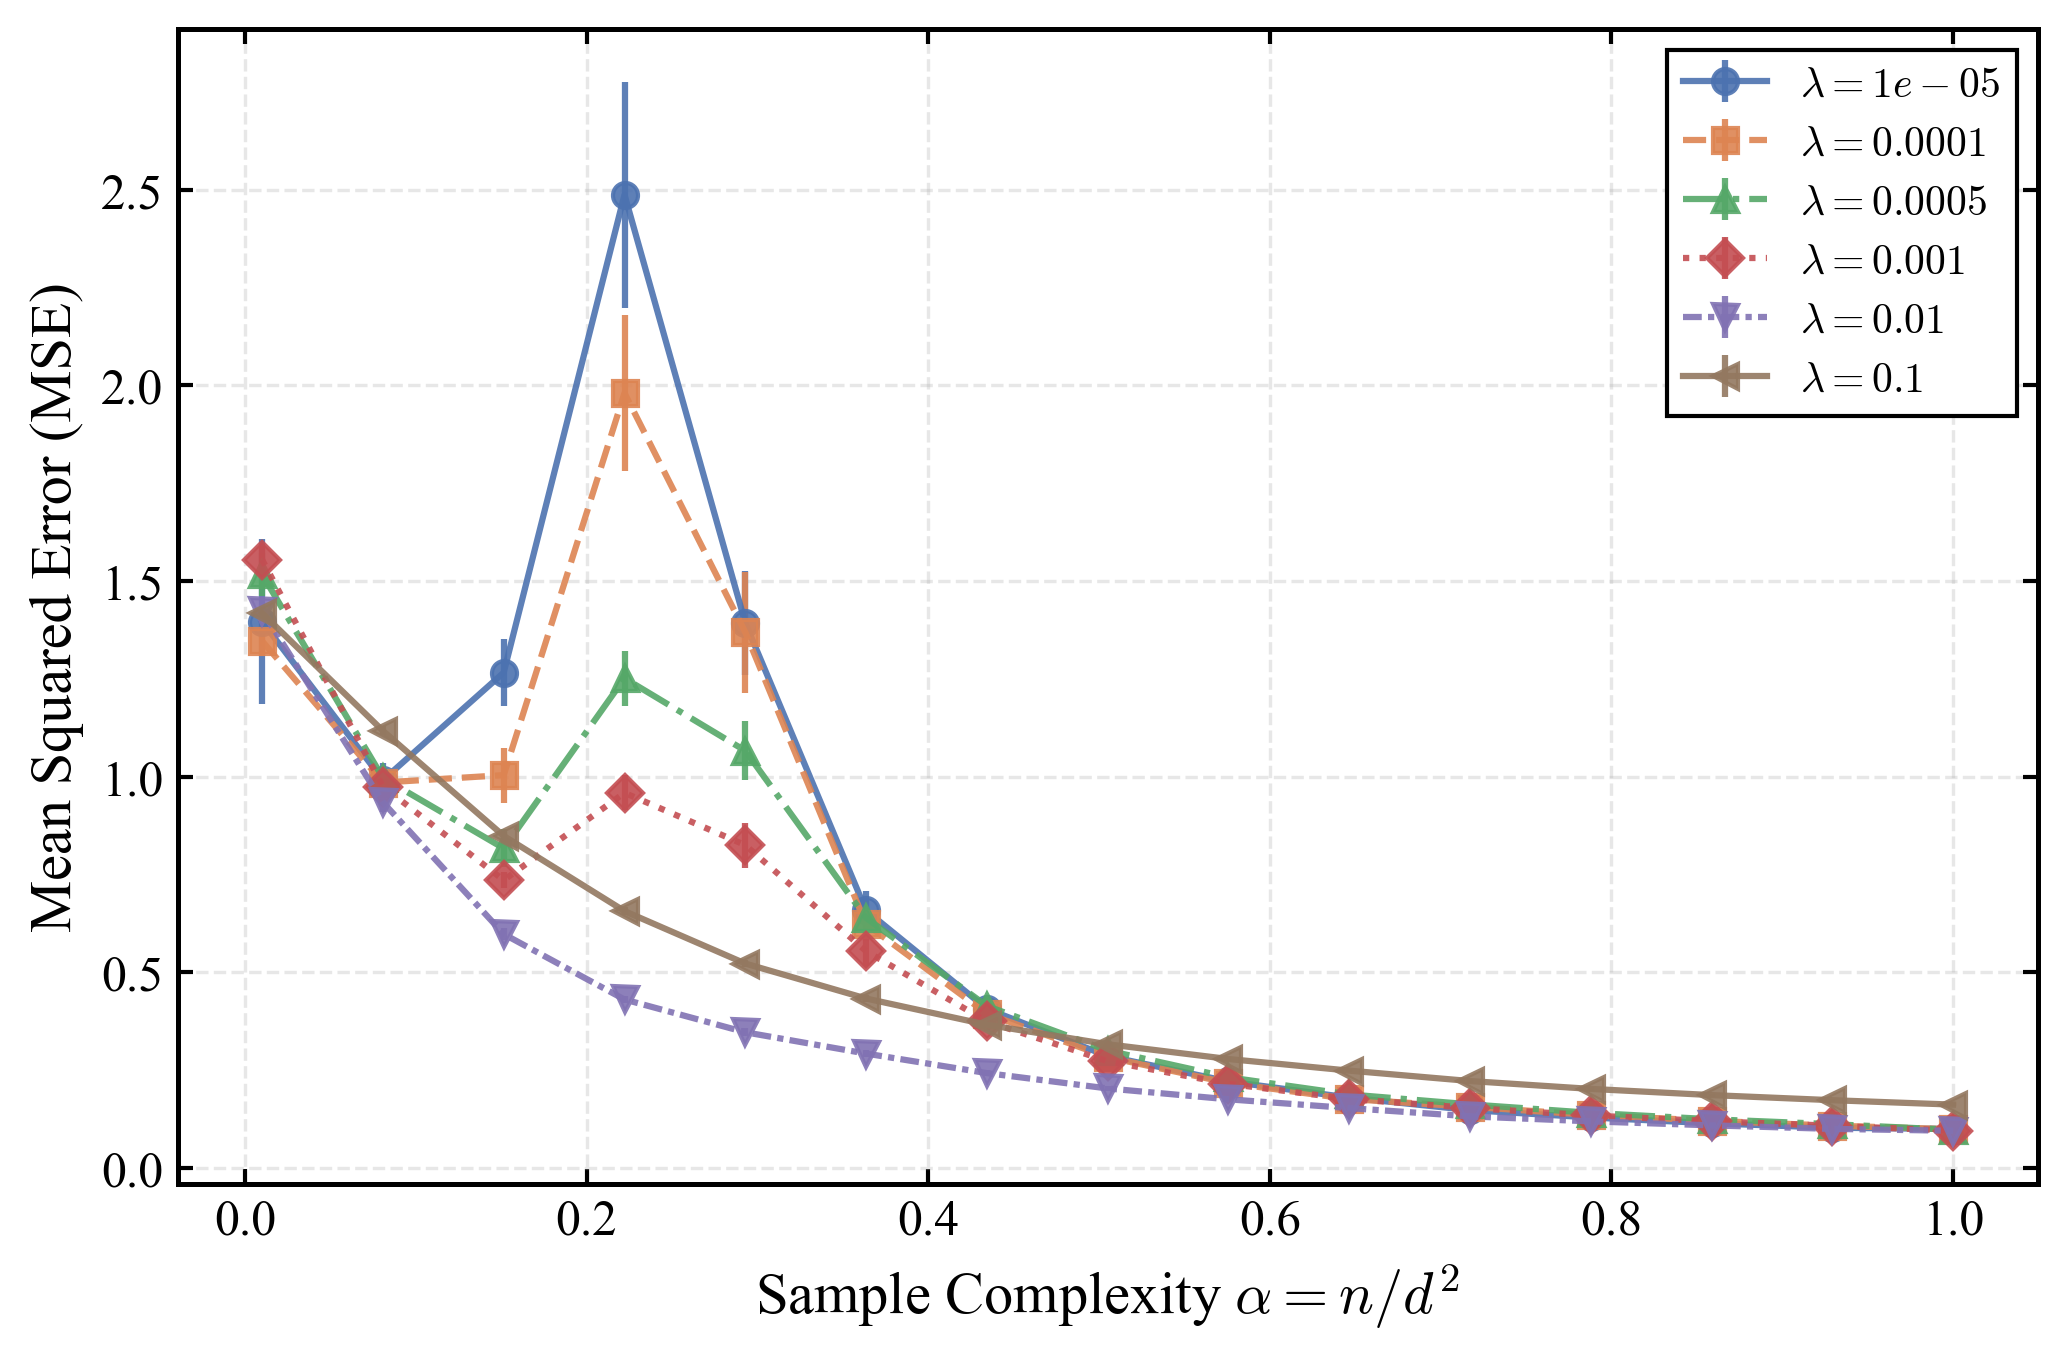

✅ Saved plot: ../results/run_20251213_1322/plots/LabelError_vs_alpha.png


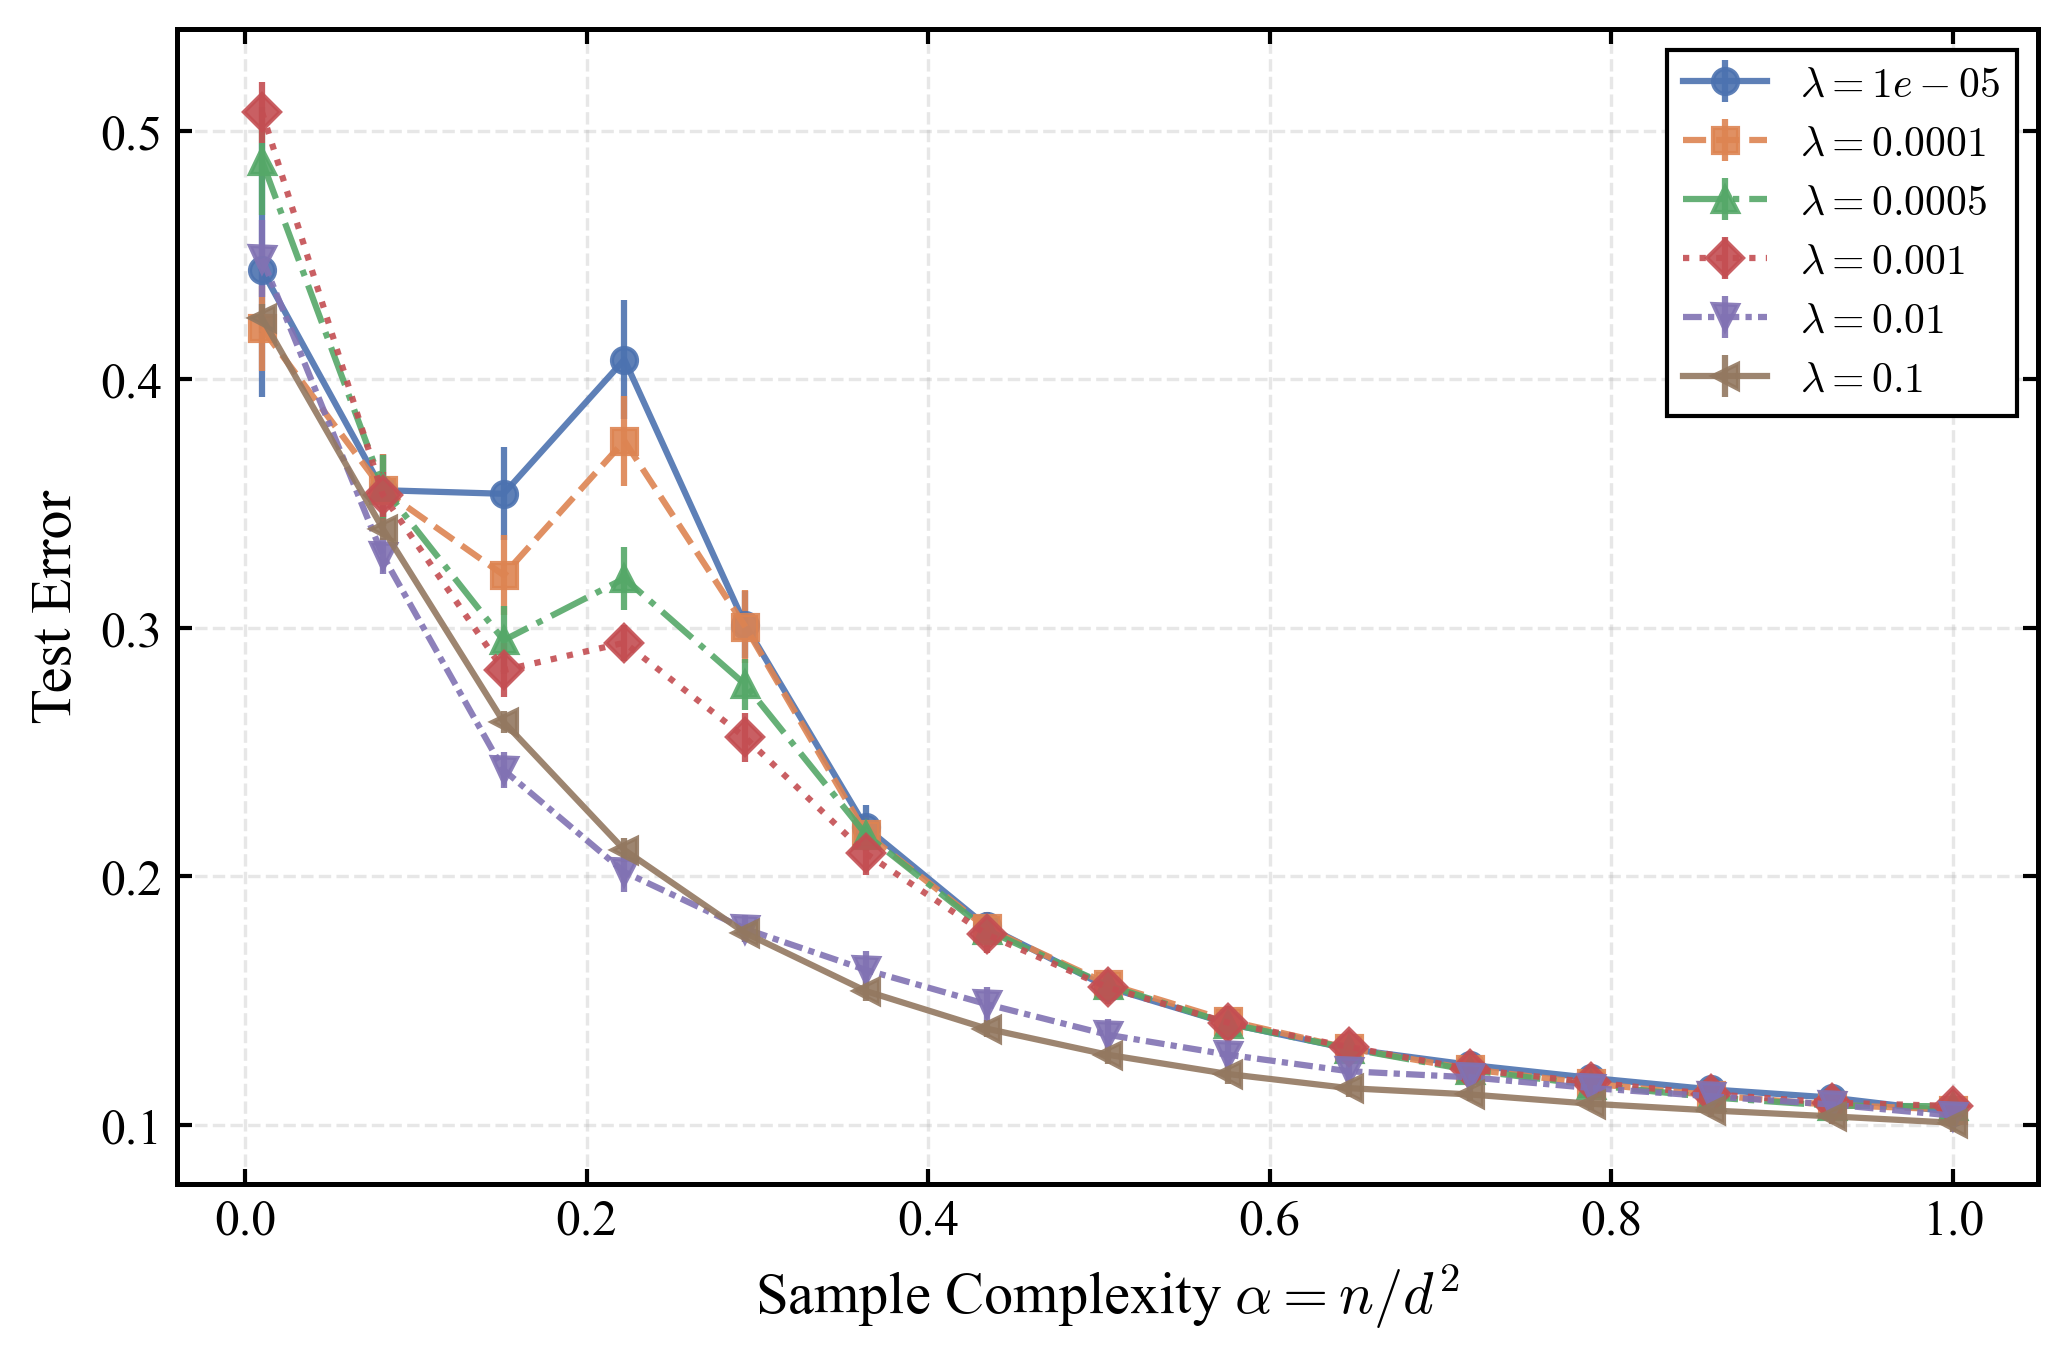

✅ Saved plot: ../results/run_20251213_1322/plots/TrainData_vs_alpha.png


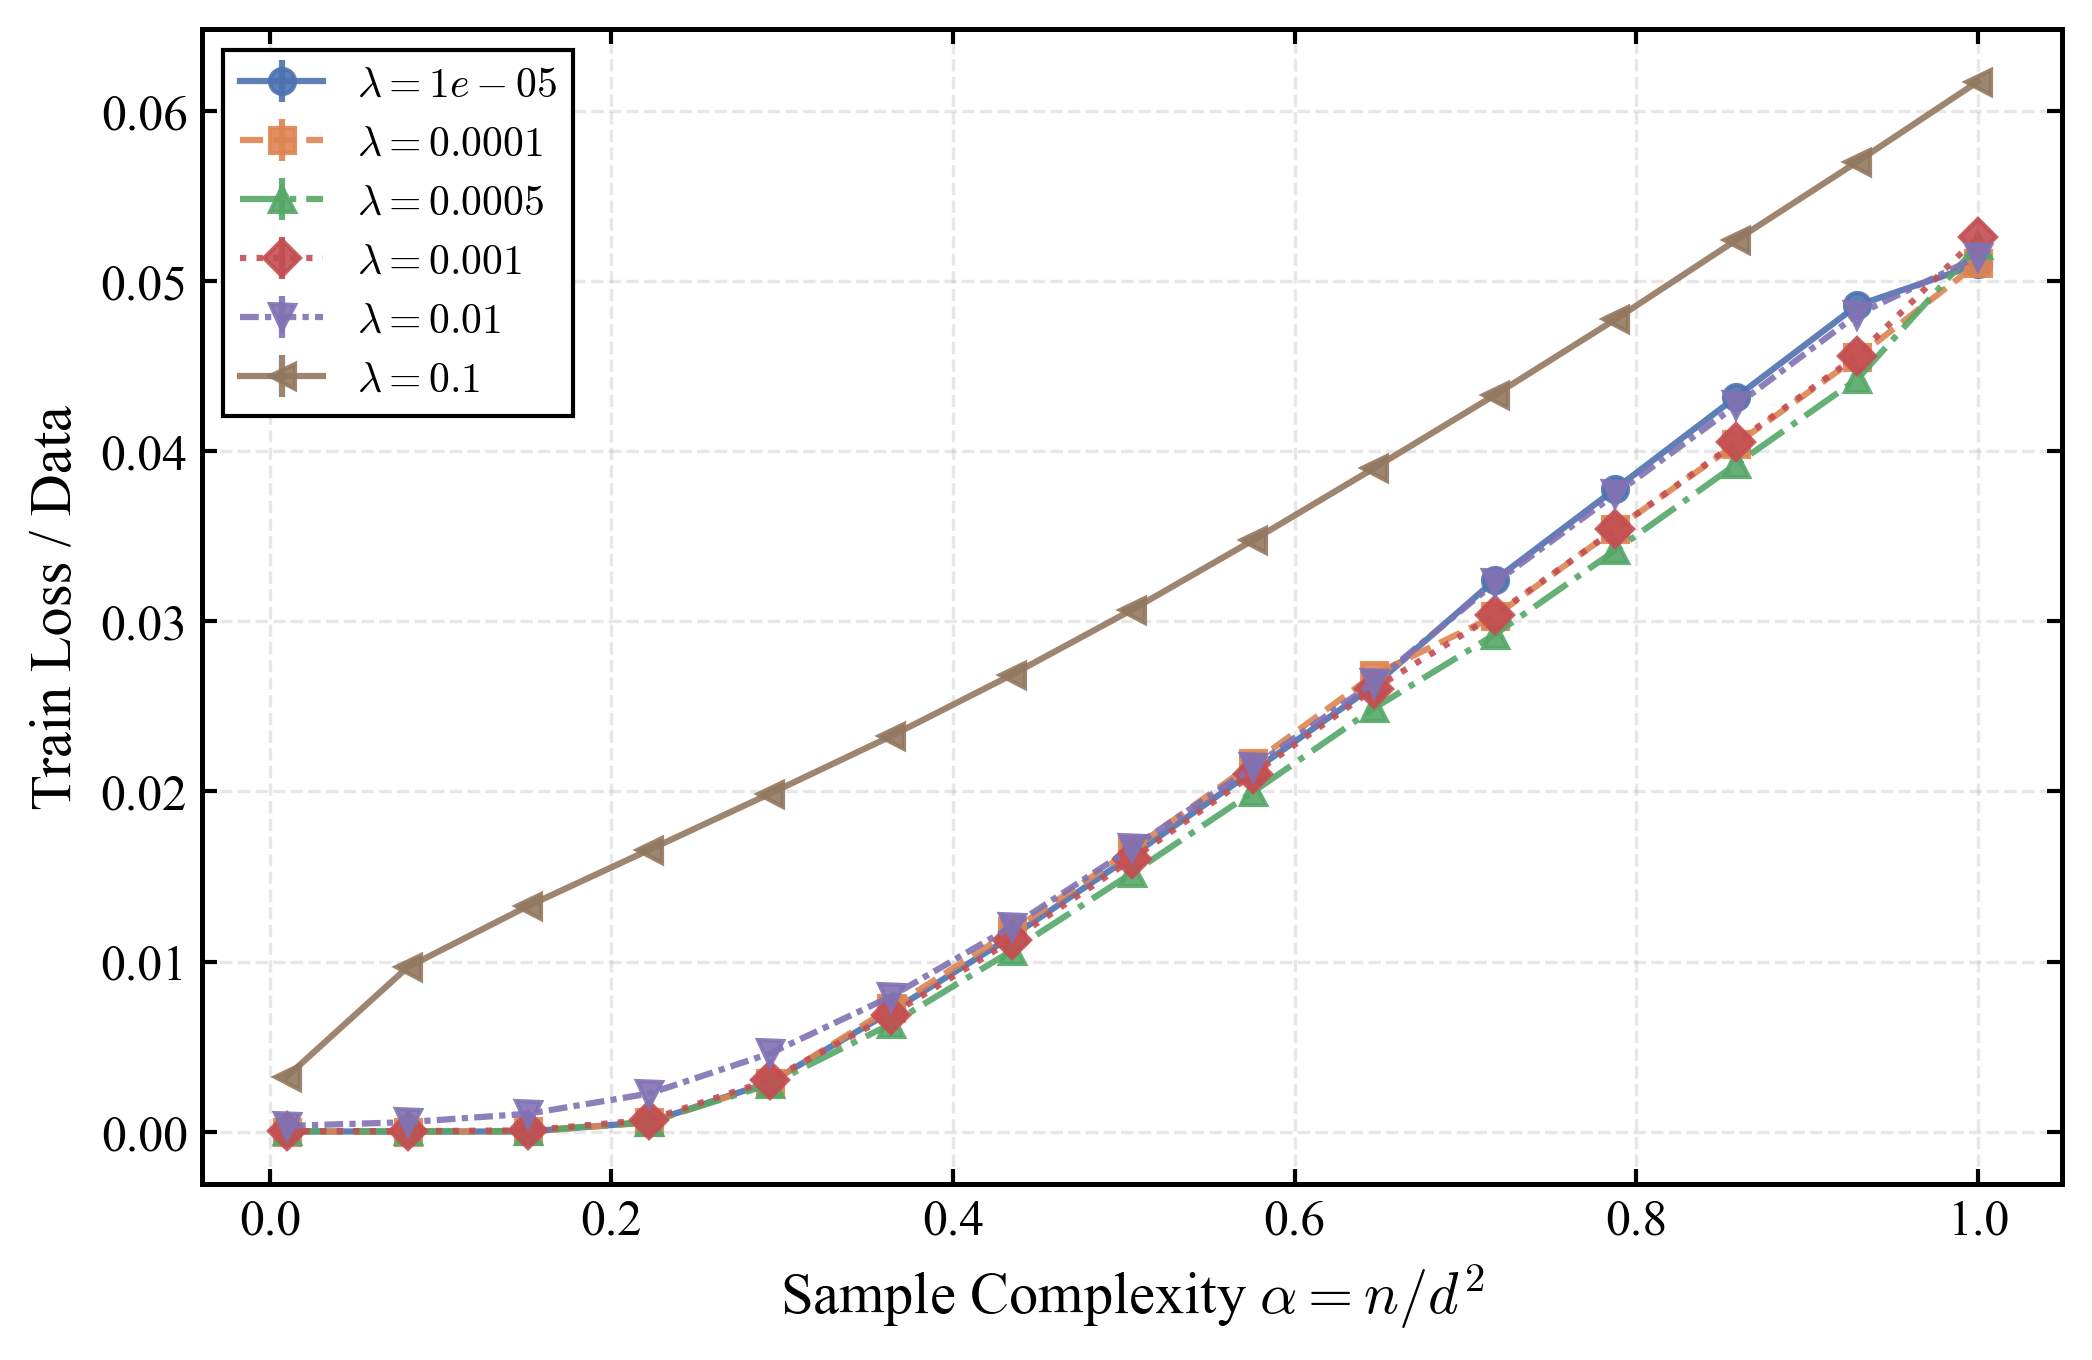

In [34]:
# --- 2. Chargement des données ---
# base_path doit être défini avant (ex: base_path = "../results/summary.csv")
if not os.path.exists(base_path):
    print(f"❌ Erreur : Fichier introuvable à {base_path}")
else:
    df = pd.read_csv(base_path)
    print(f"✅ Summary loaded ({len(df)} rows) from {base_path}")

# --- 3. Définition des Styles (Couleurs & Marqueurs) ---
# Palette automatique selon le nombre de lambdas
unique_lams = sorted(df["lam"].unique())
colors = sns.color_palette("deep", n_colors=len(unique_lams))
markers = ['o', 's', '^', 'D', 'v', '<', '>']
linestyles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]

# Gestion personnalisée des ticks X (comme demandé)
alpha_min, alpha_max = df["alpha"].min(), df["alpha"].max()
# On peut forcer 5 ticks proprement arrondis si besoin
custom_xticks = np.linspace(alpha_min, alpha_max, 5) 

# --- 4. Fonction de Plot Générique (DRY Principle) ---
def plot_academic_metric(df, y_col, y_err_col, ylabel, filename):
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # Boucle sur les Lambdas
    for i, lam in enumerate(unique_lams):
        subset = df[df["lam"] == lam].sort_values("alpha")
        
        # Sélection cyclique du style
        fmt_color = colors[i % len(colors)]
        fmt_marker = markers[i % len(markers)]
        fmt_ls = linestyles[i % len(linestyles)]
        
        ax.errorbar(
            subset["alpha"], 
            subset[y_col], 
            yerr=subset.get(y_err_col, 0),
            label=fr"$\lambda={lam}$", # Label LaTeX
            color=fmt_color,
            marker=fmt_marker,
            linestyle=fmt_ls,
            capsize=0,       # Jolis chapeaux sur les barres d'erreur
            elinewidth=1.5,
            alpha=0.9
        )

    # --- Labels et Ticks ---
    ax.set_xlabel(r"Sample Complexity $\alpha = n / d^2$")
    ax.set_ylabel(ylabel)
    
    # Appliquer les ticks réduits si demandé
    # ax.set_xticks(custom_xticks) 
    # ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))

    # --- STYLE BOÎTE (Box Style) ---
    ax.set_axisbelow(True) 
    ax.tick_params(direction='in', top=True, right=True, which='both', width=1.0)
    
    # Bordures noires solides
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.2)
    
    # Légende
    ax.legend(frameon=True, fancybox=False, edgecolor='black', framealpha=1.0, loc='best')
    
    # Sauvegarde
    save_full = os.path.join(plot_path, filename)
    plt.savefig(save_full)
    print(f"✅ Saved plot: {save_full}")
    plt.show()

# --- 5. Génération des 3 Graphiques ---

# 1. MSE
plot_academic_metric(
    df, 
    y_col="MSE_mean", 
    y_err_col="MSE_std", 
    ylabel="Mean Squared Error (MSE)", 
    filename="MSE_vs_alpha.png"
)

# 2. Label Error
plot_academic_metric(
    df, 
    y_col="label_err_mean_noise", 
    y_err_col="label_err_std_noise", 
    ylabel="Test Error", 
    filename="LabelError_vs_alpha.png"
)

# 3. Train Data
plot_academic_metric(
    df, 
    y_col="train_data_mean", 
    y_err_col="train_data_std", 
    ylabel="Train Loss / Data", 
    filename="TrainData_vs_alpha.png"
)

## 3. Singular values distributions per $\lambda$

🎯 Target Lambda 0.001 found at index 2
📂 Found 15 W_runs files.
✅ Saved plot: ../results/run_20251213_1322/plots/SVD_Dist_lambda_0.001_W_runs_0.png


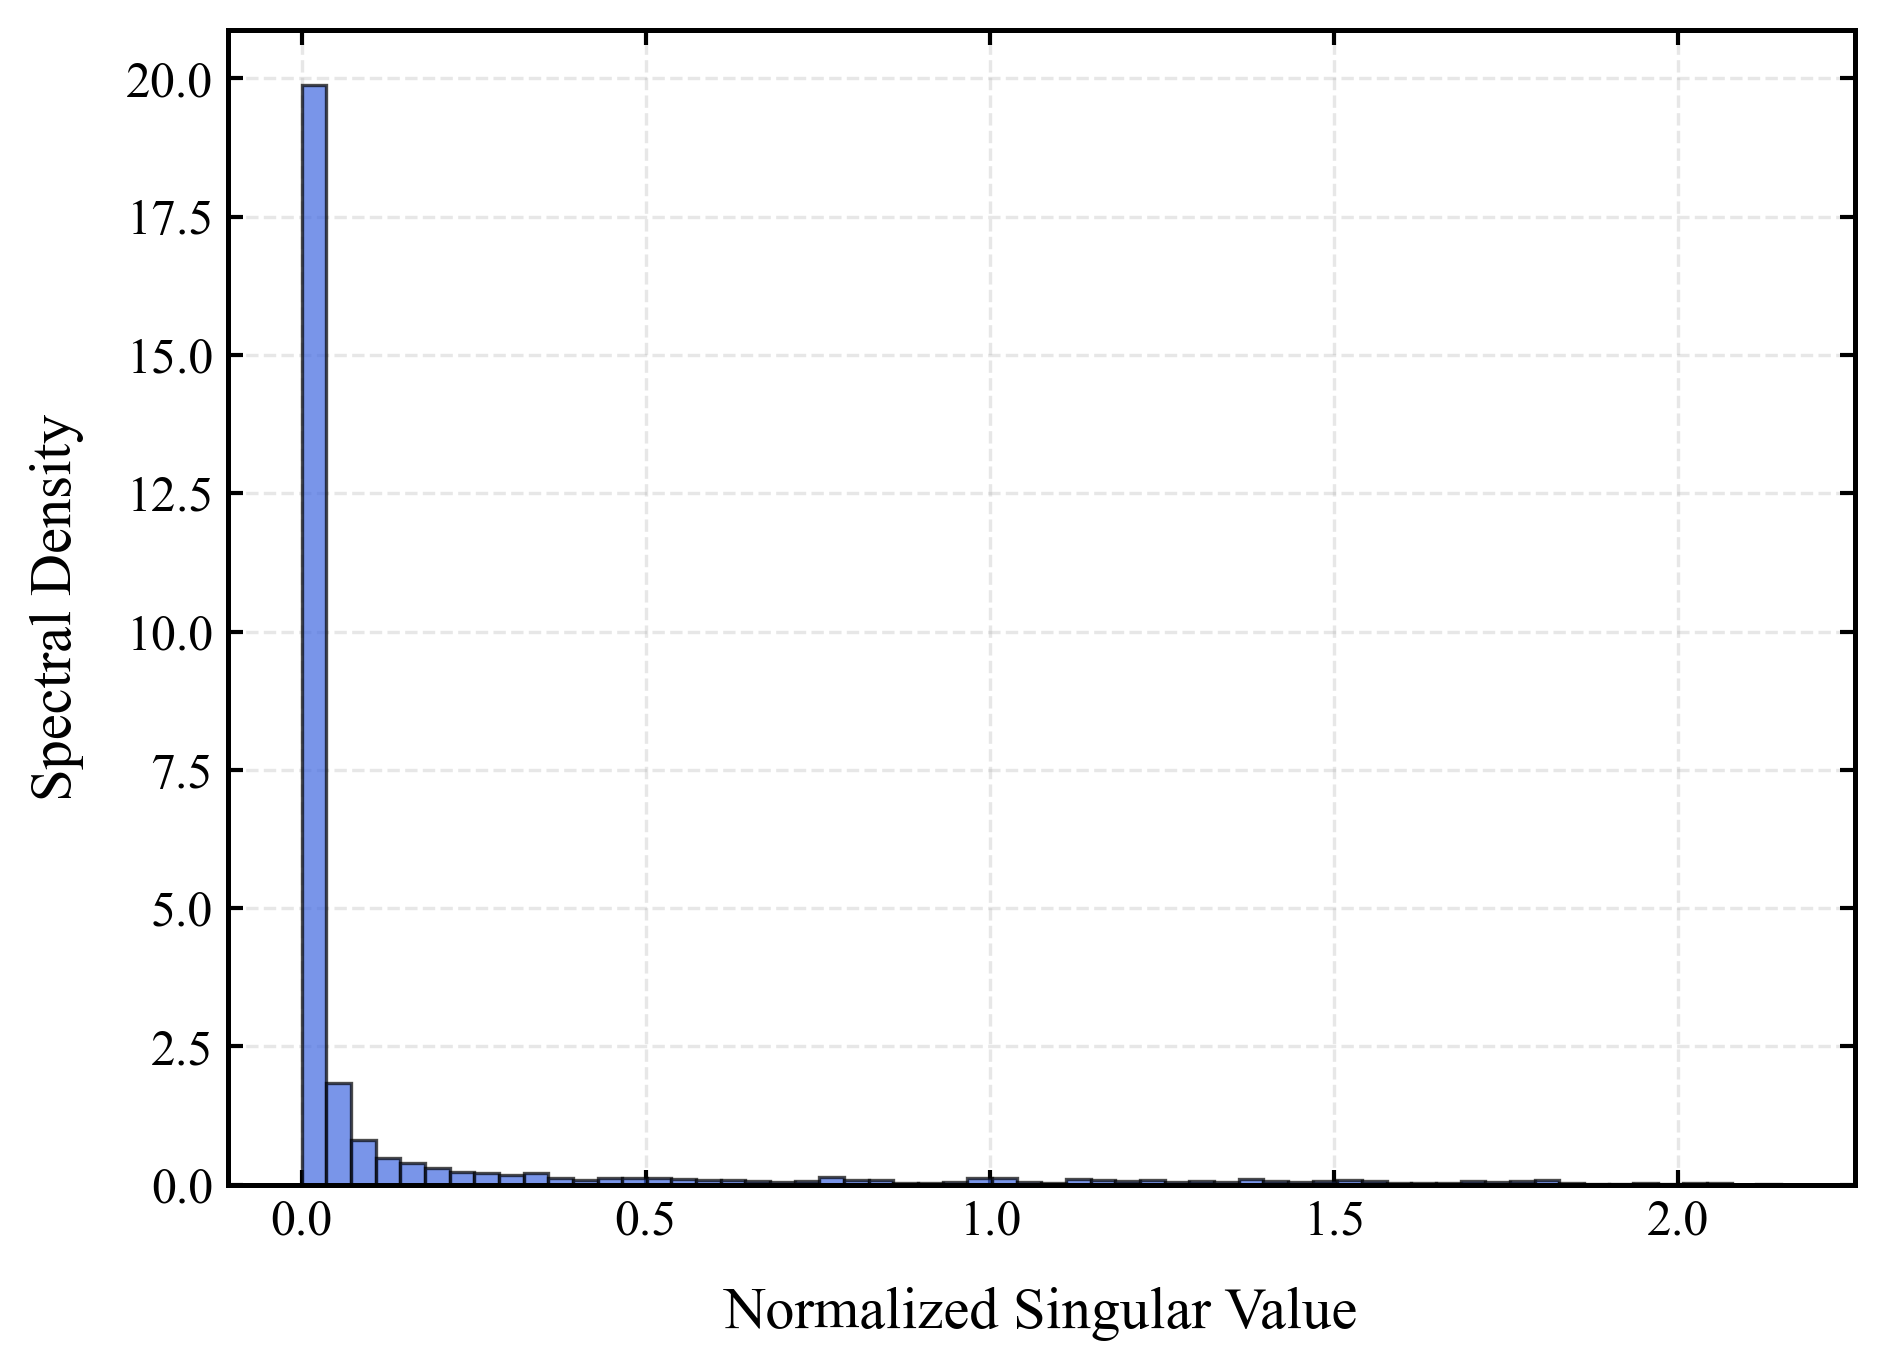

✅ Saved plot: ../results/run_20251213_1322/plots/SVD_Dist_lambda_0.001_W_runs_1.png


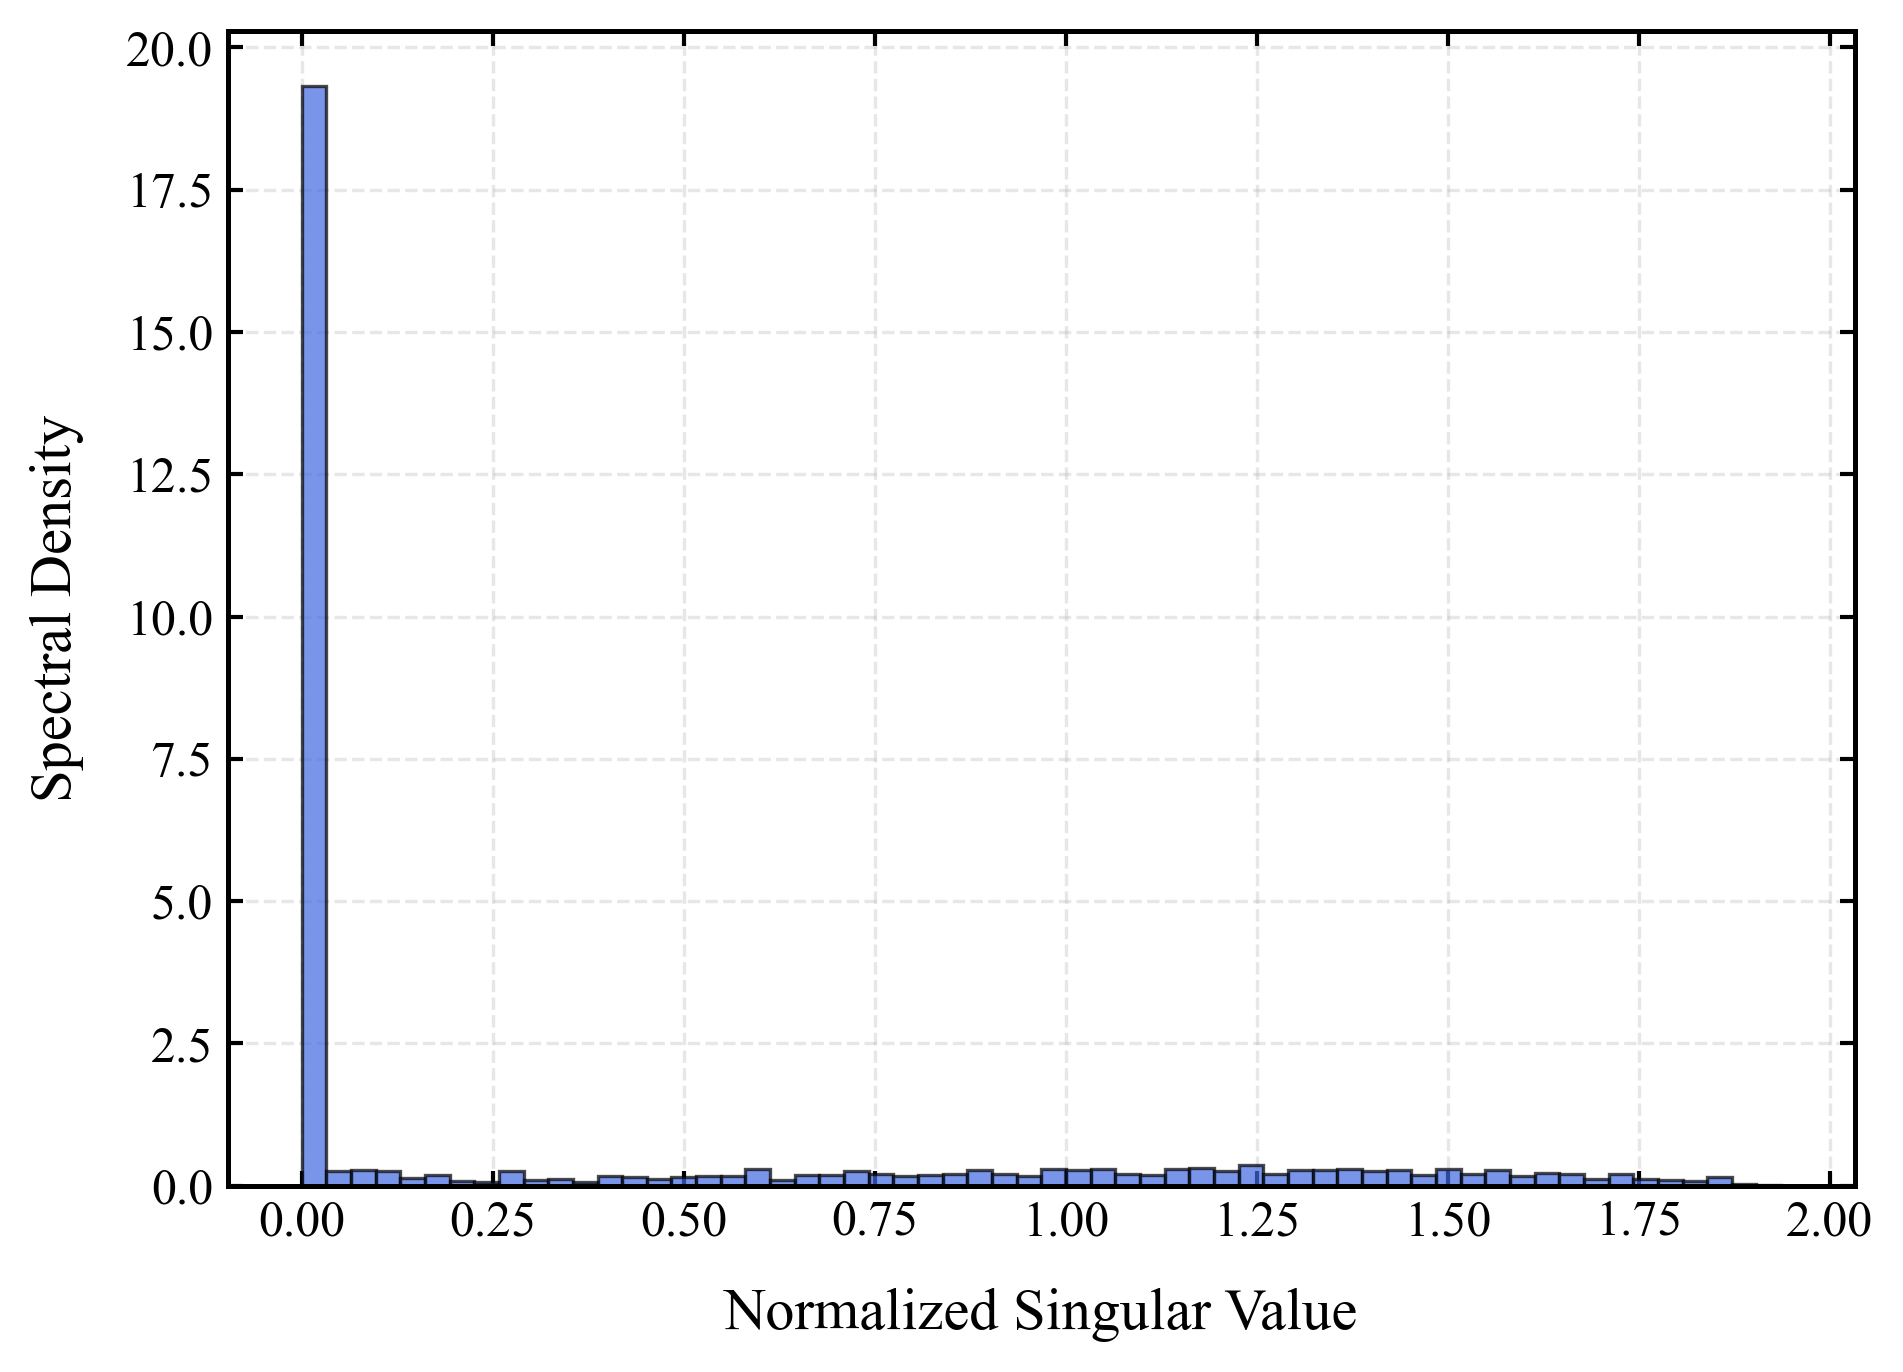

✅ Saved plot: ../results/run_20251213_1322/plots/SVD_Dist_lambda_0.001_W_runs_10.png


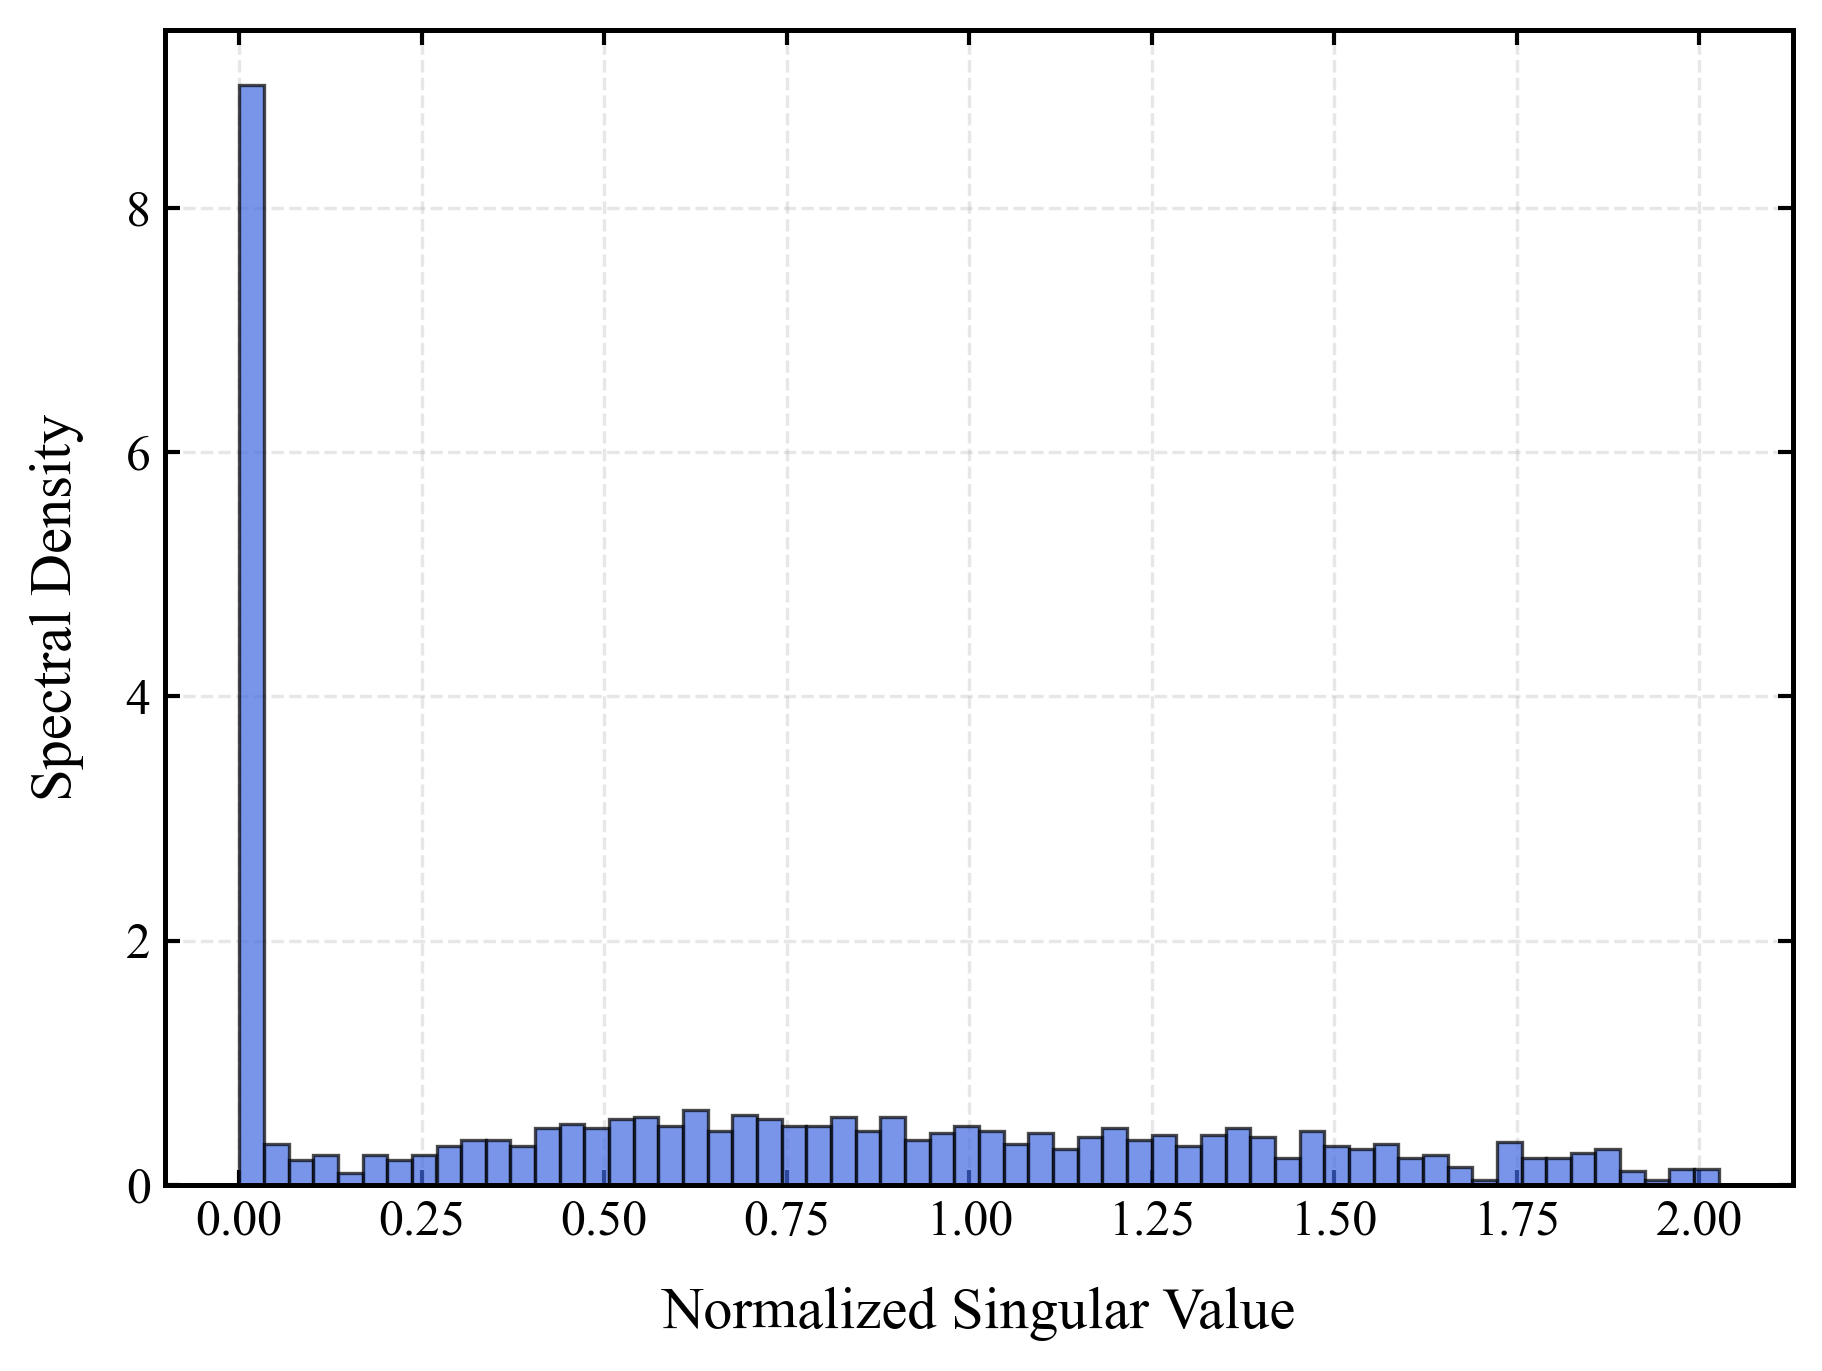

✅ Saved plot: ../results/run_20251213_1322/plots/SVD_Dist_lambda_0.001_W_runs_11.png


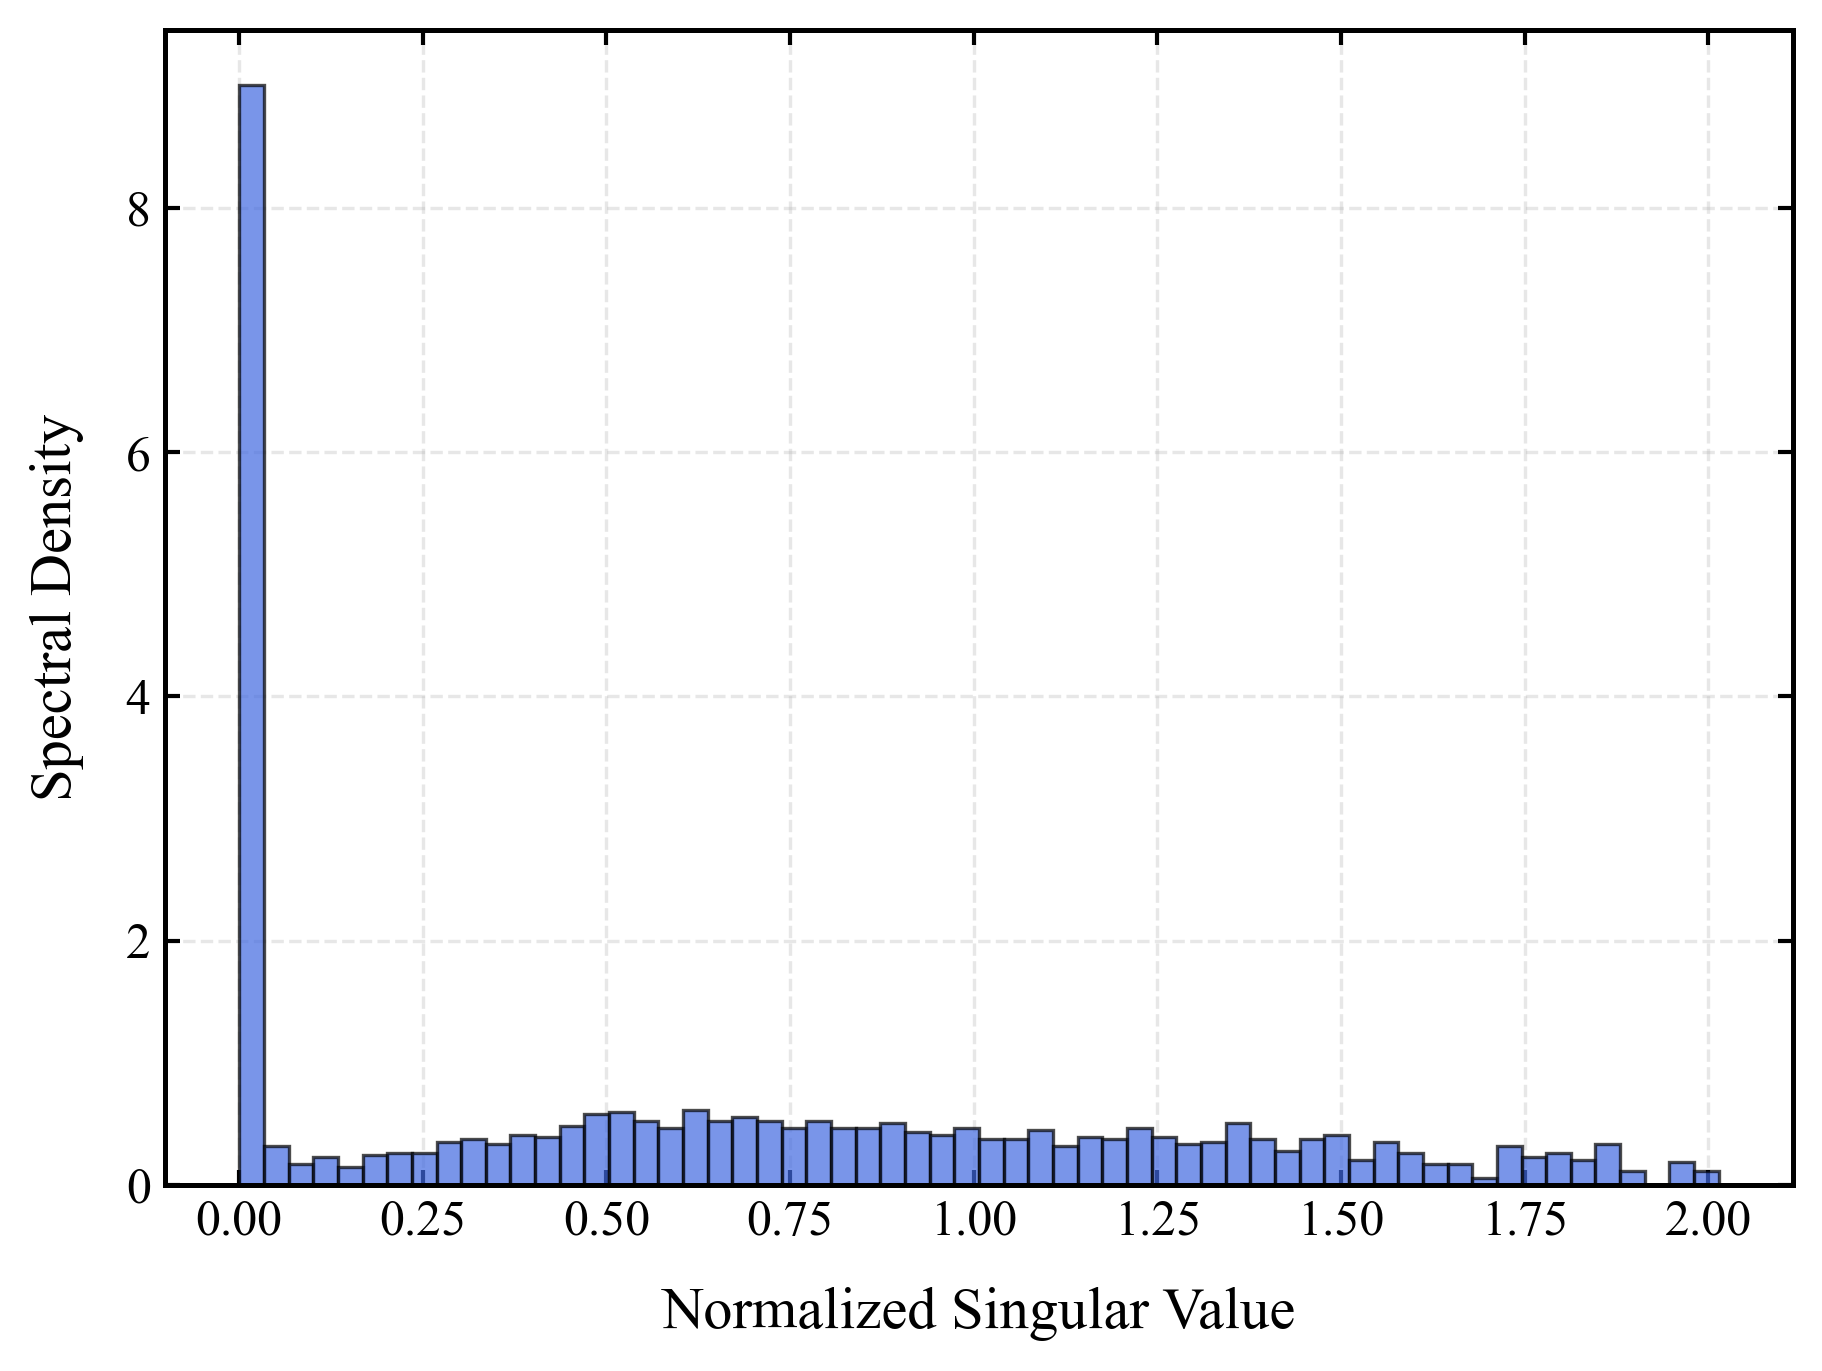

✅ Saved plot: ../results/run_20251213_1322/plots/SVD_Dist_lambda_0.001_W_runs_12.png


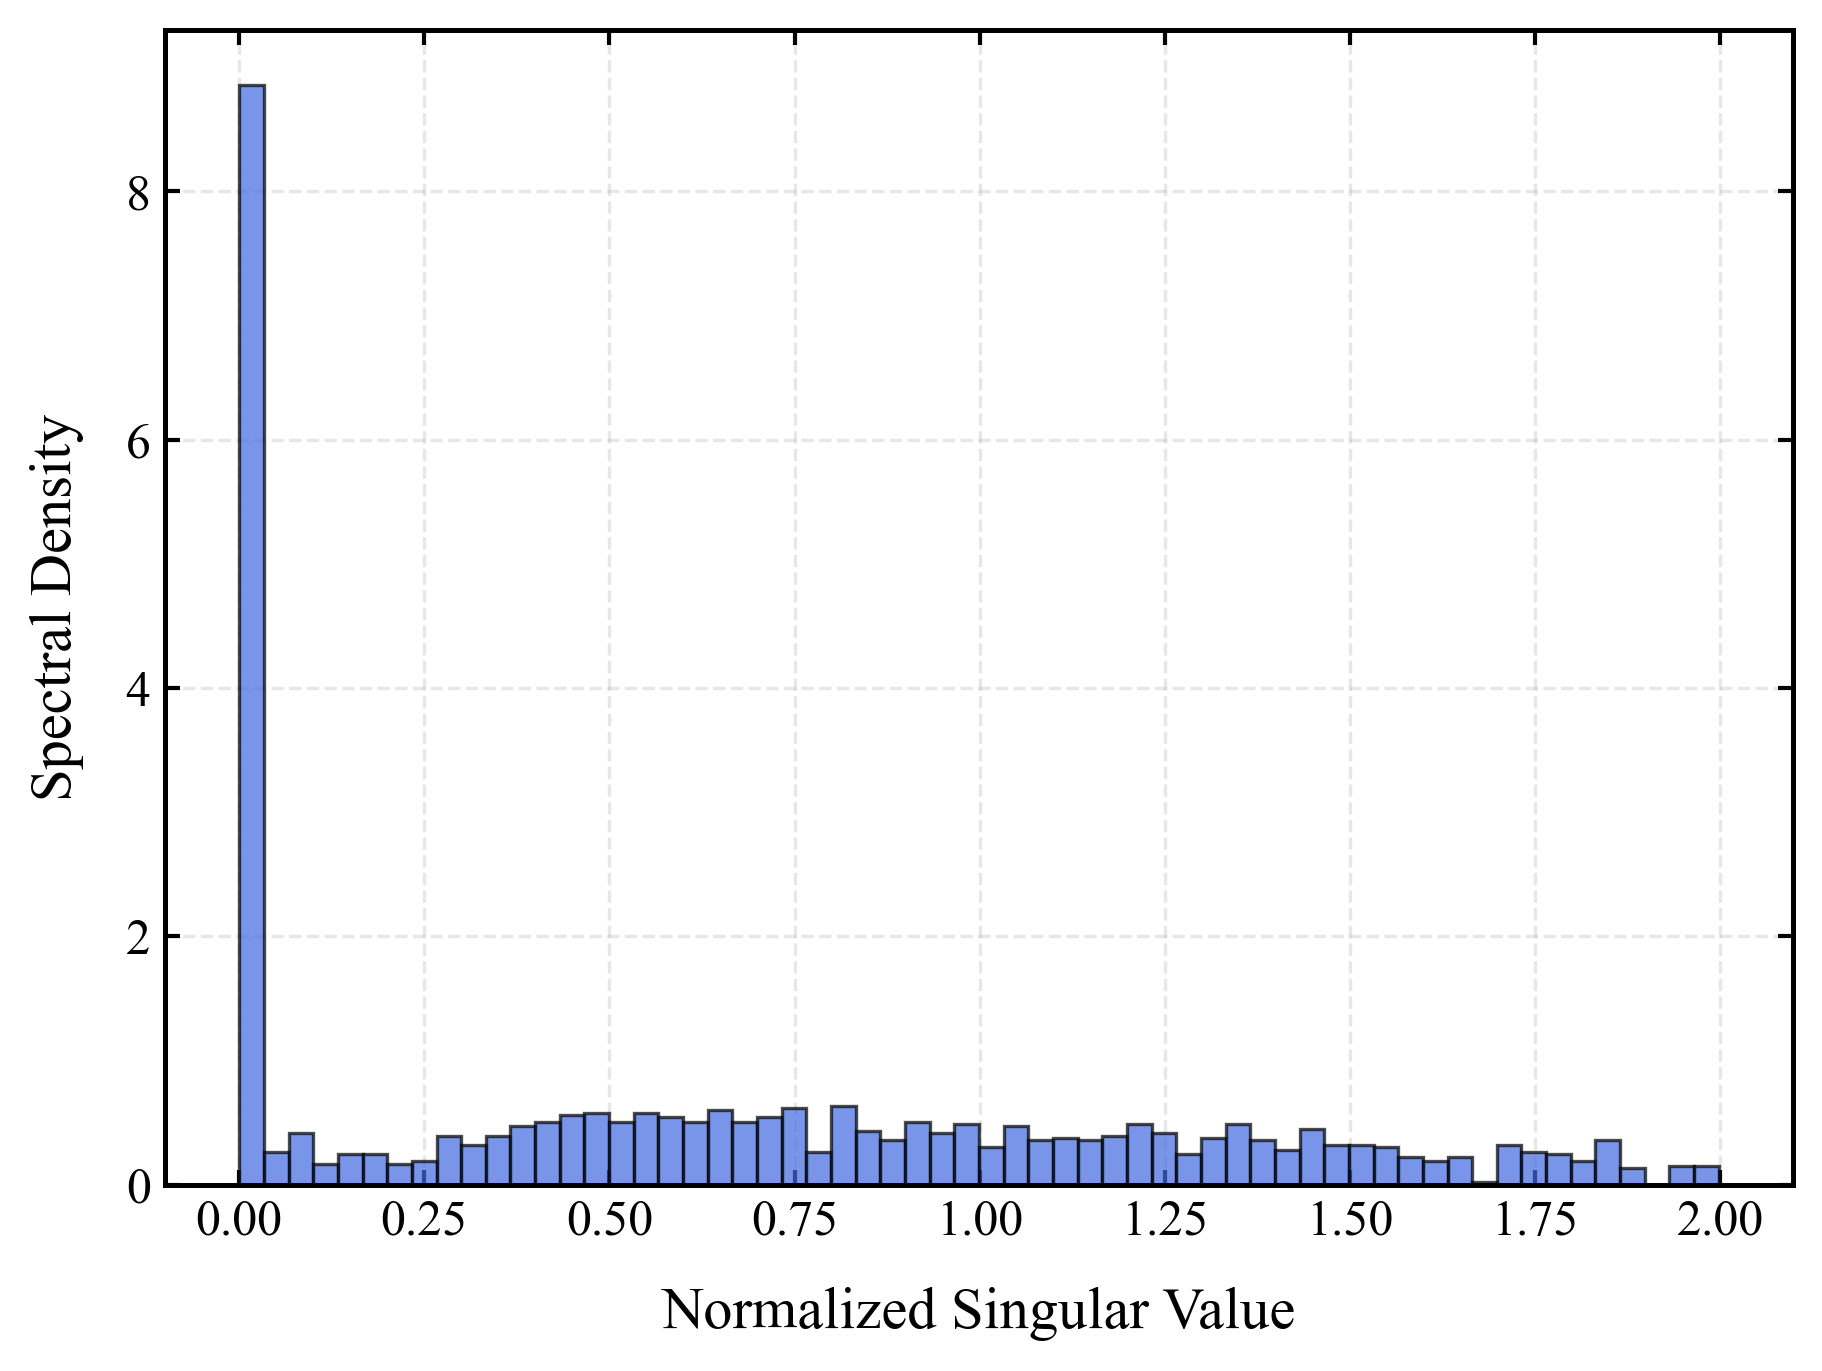

✅ Saved plot: ../results/run_20251213_1322/plots/SVD_Dist_lambda_0.001_W_runs_13.png


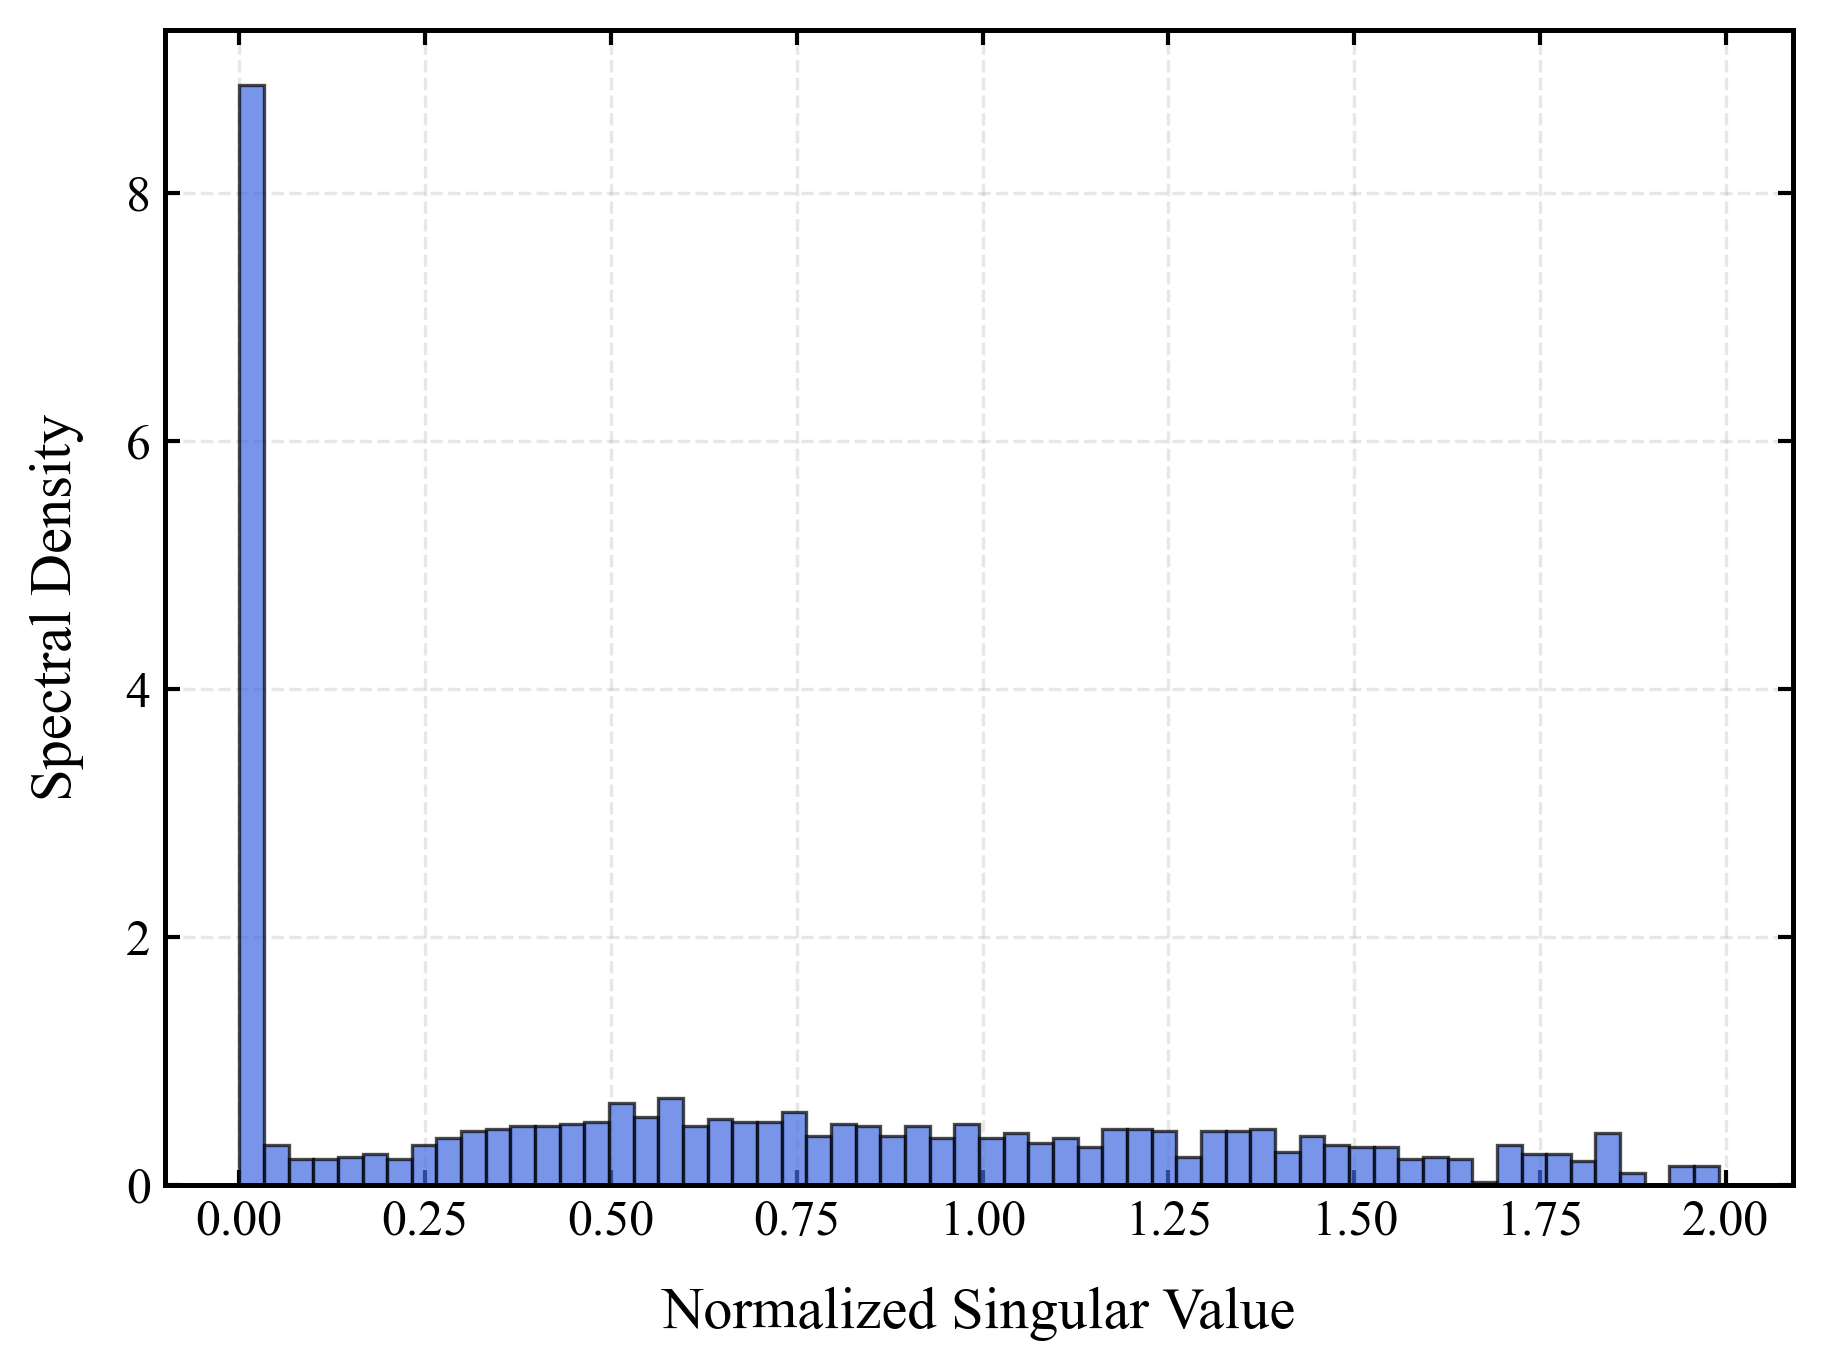

✅ Saved plot: ../results/run_20251213_1322/plots/SVD_Dist_lambda_0.001_W_runs_14.png


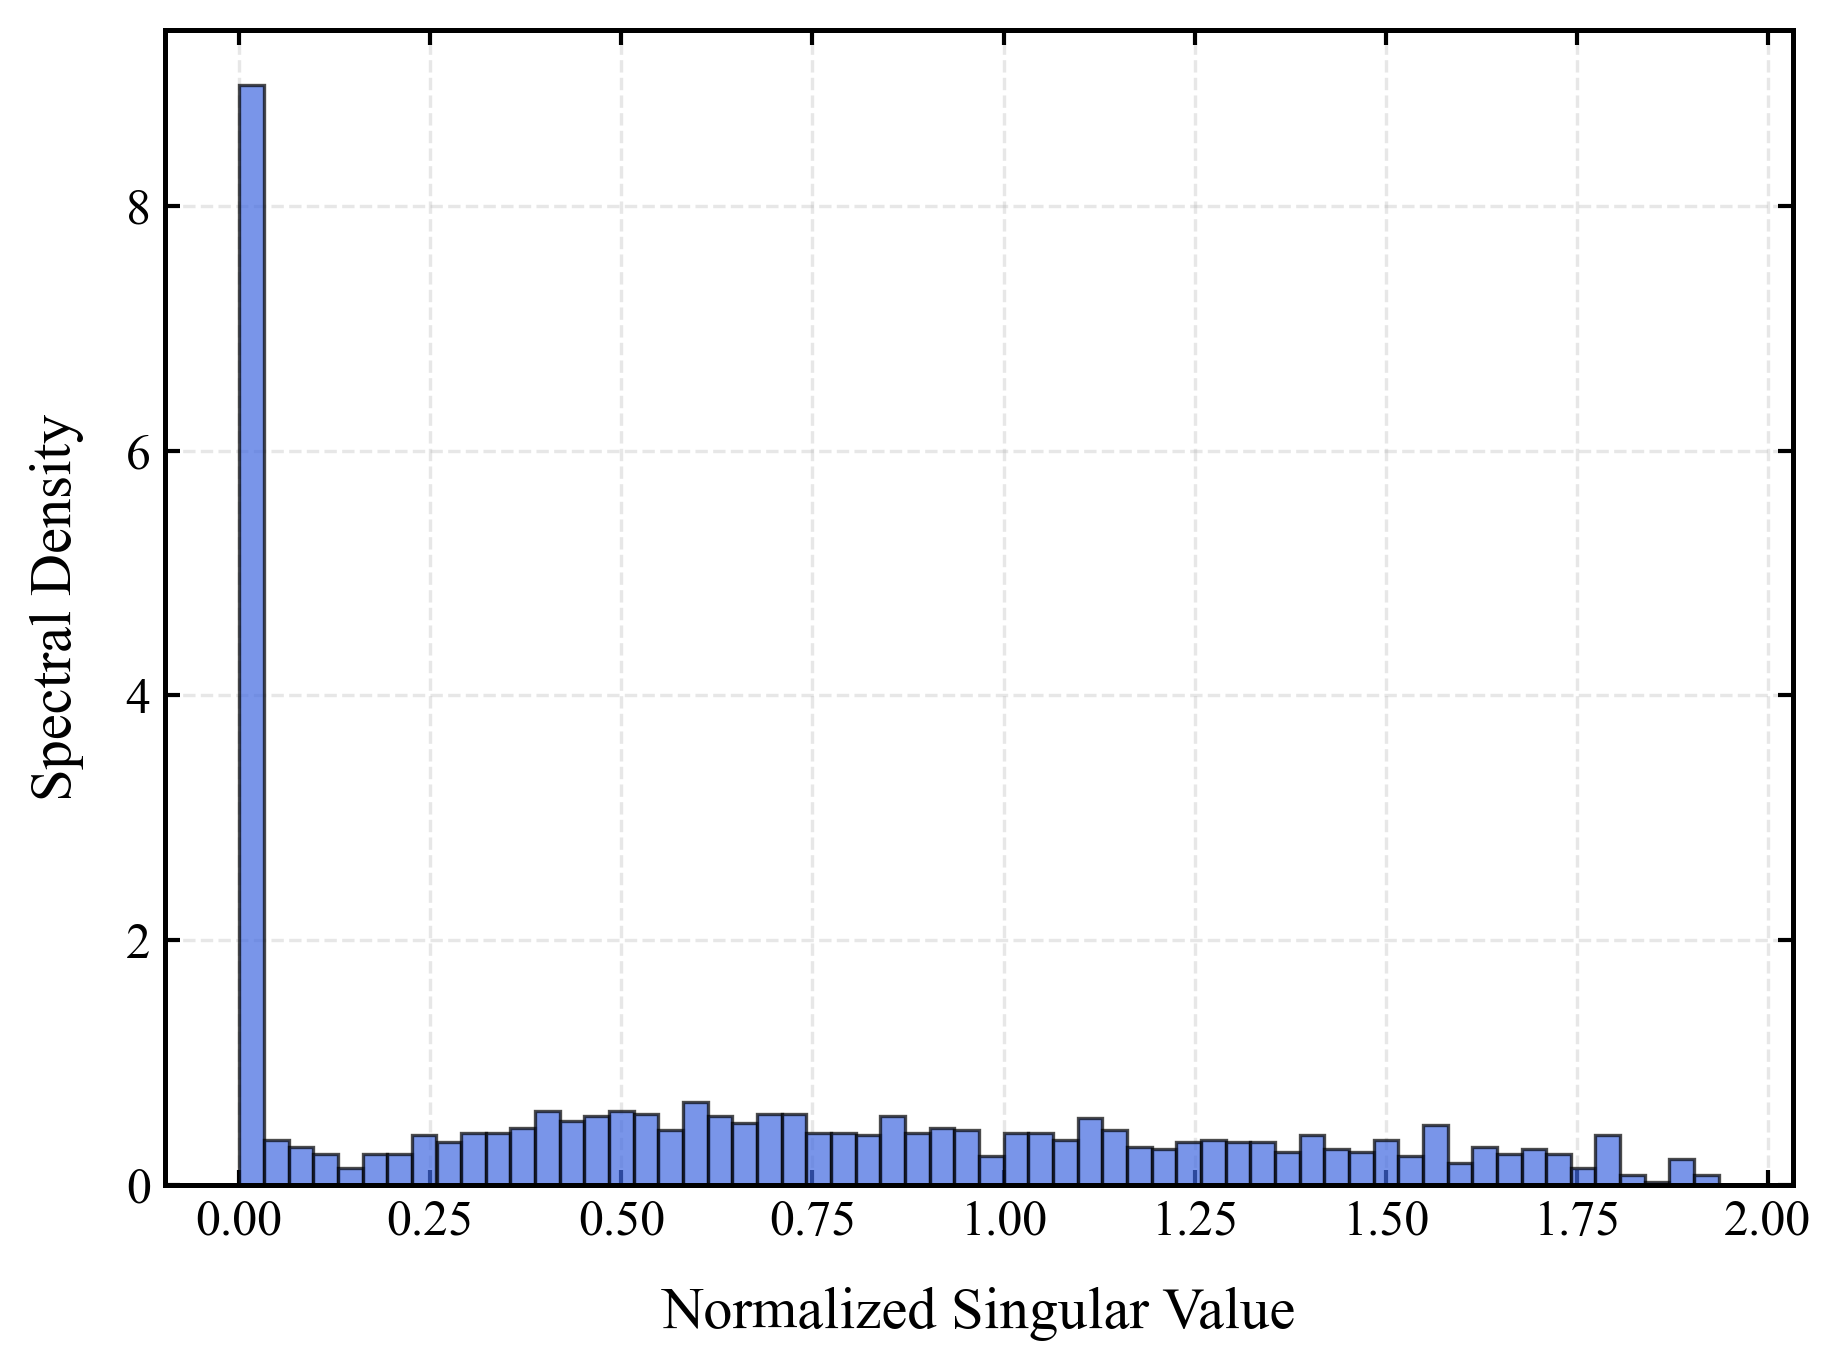

✅ Saved plot: ../results/run_20251213_1322/plots/SVD_Dist_lambda_0.001_W_runs_2.png


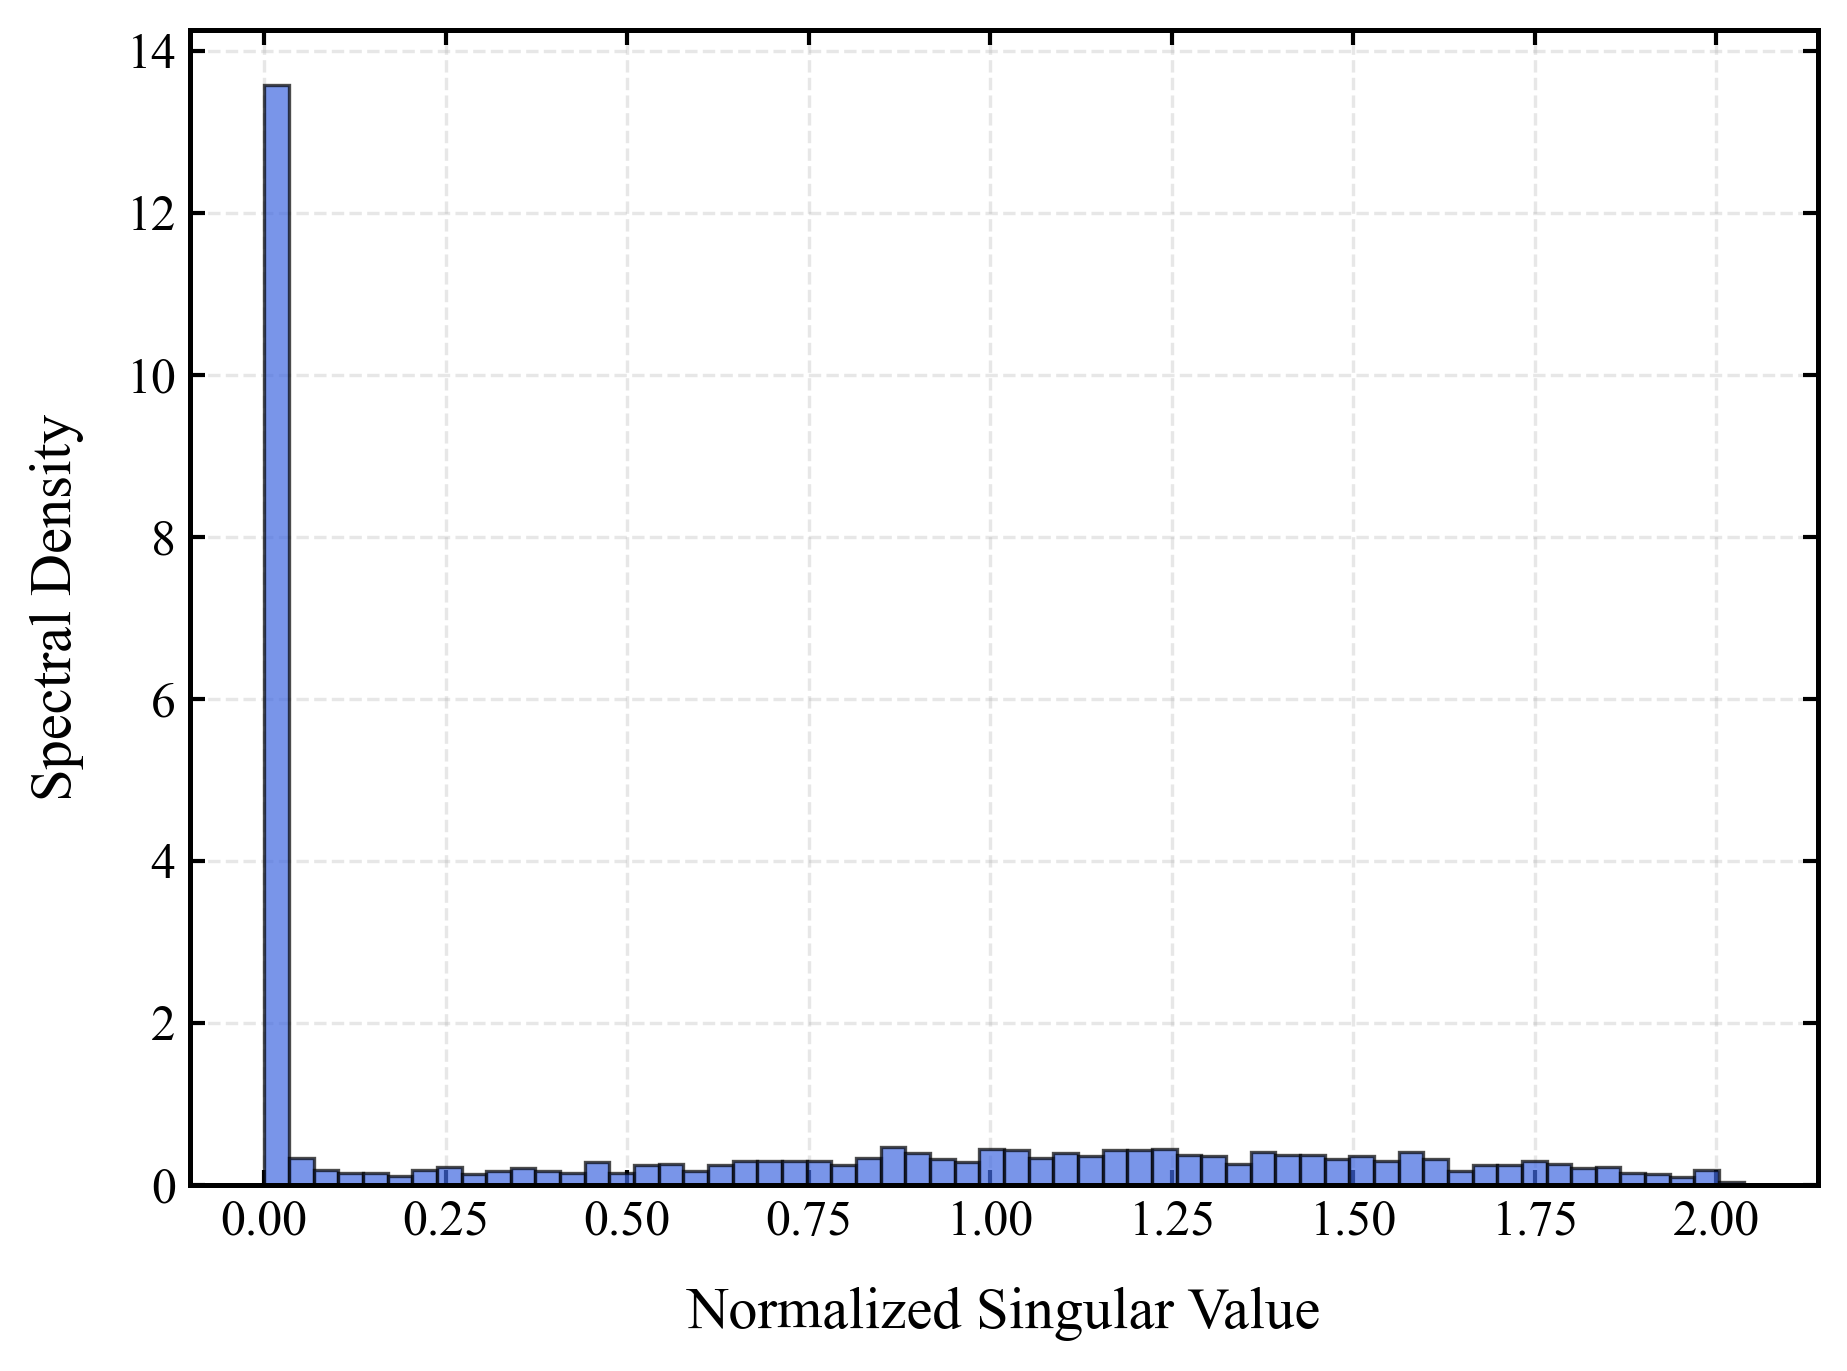

✅ Saved plot: ../results/run_20251213_1322/plots/SVD_Dist_lambda_0.001_W_runs_3.png


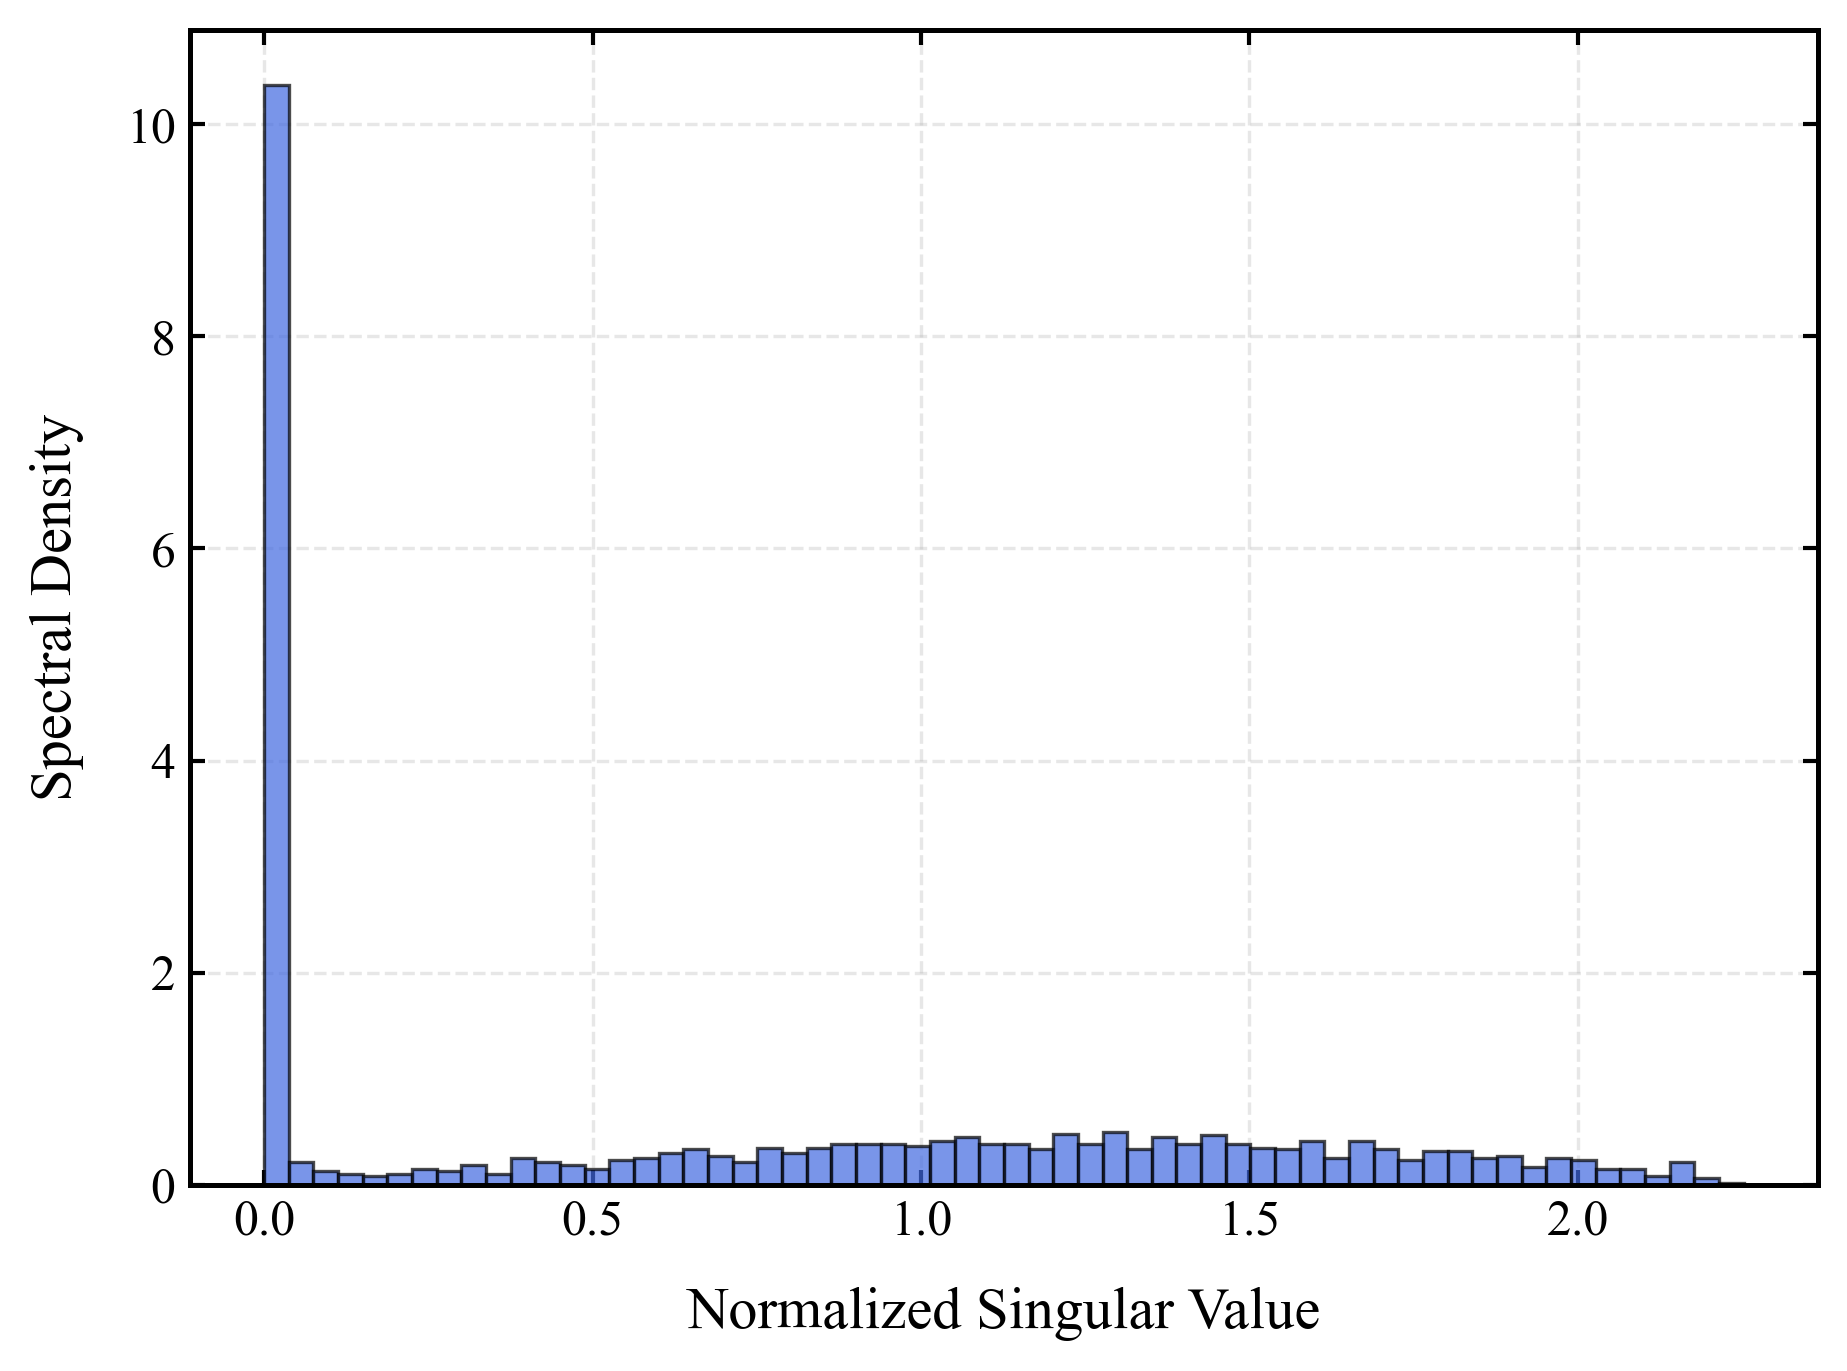

✅ Saved plot: ../results/run_20251213_1322/plots/SVD_Dist_lambda_0.001_W_runs_4.png


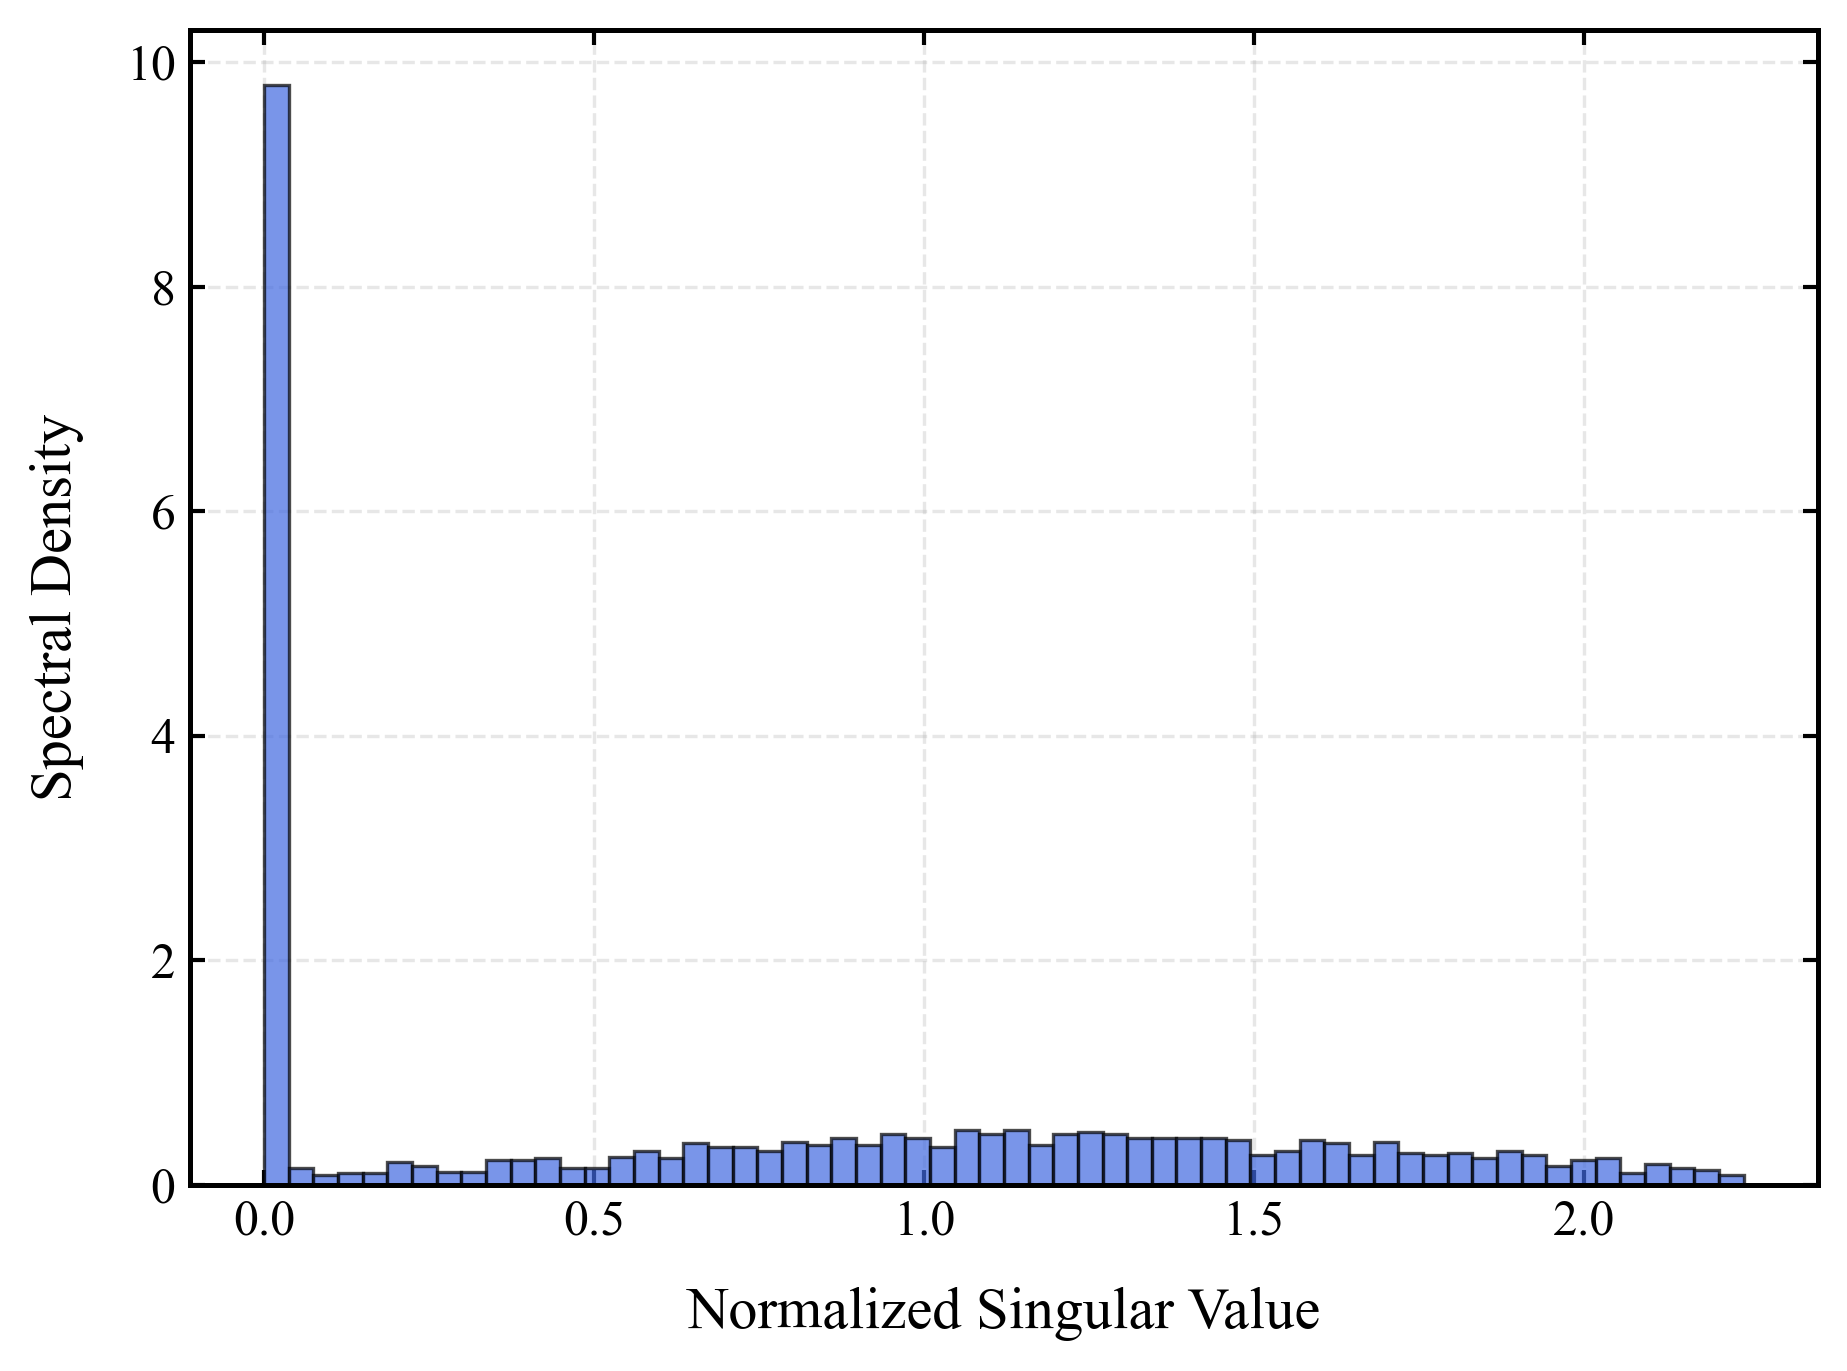

✅ Saved plot: ../results/run_20251213_1322/plots/SVD_Dist_lambda_0.001_W_runs_5.png


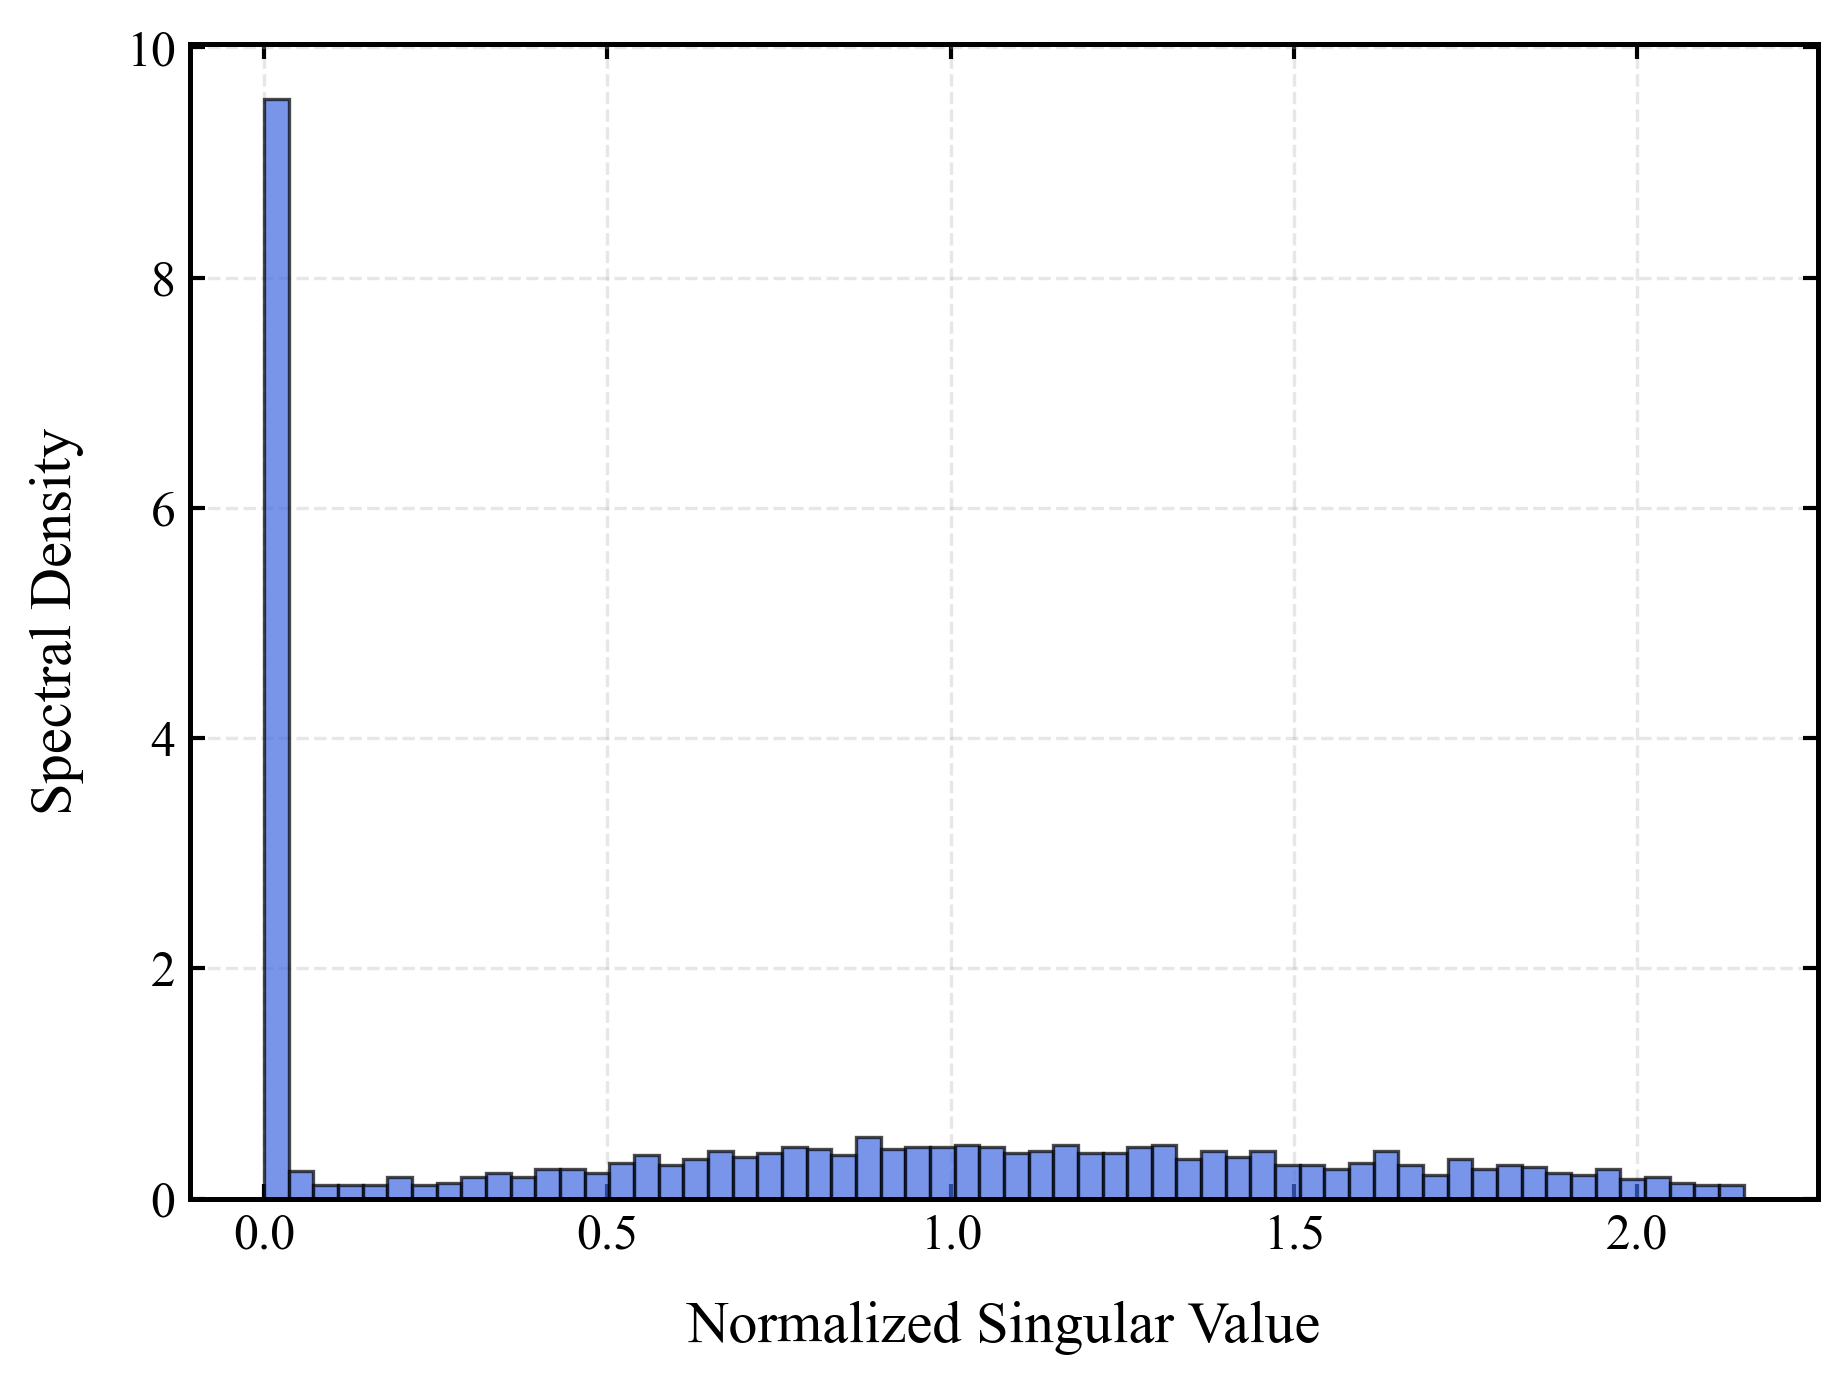

✅ Saved plot: ../results/run_20251213_1322/plots/SVD_Dist_lambda_0.001_W_runs_6.png


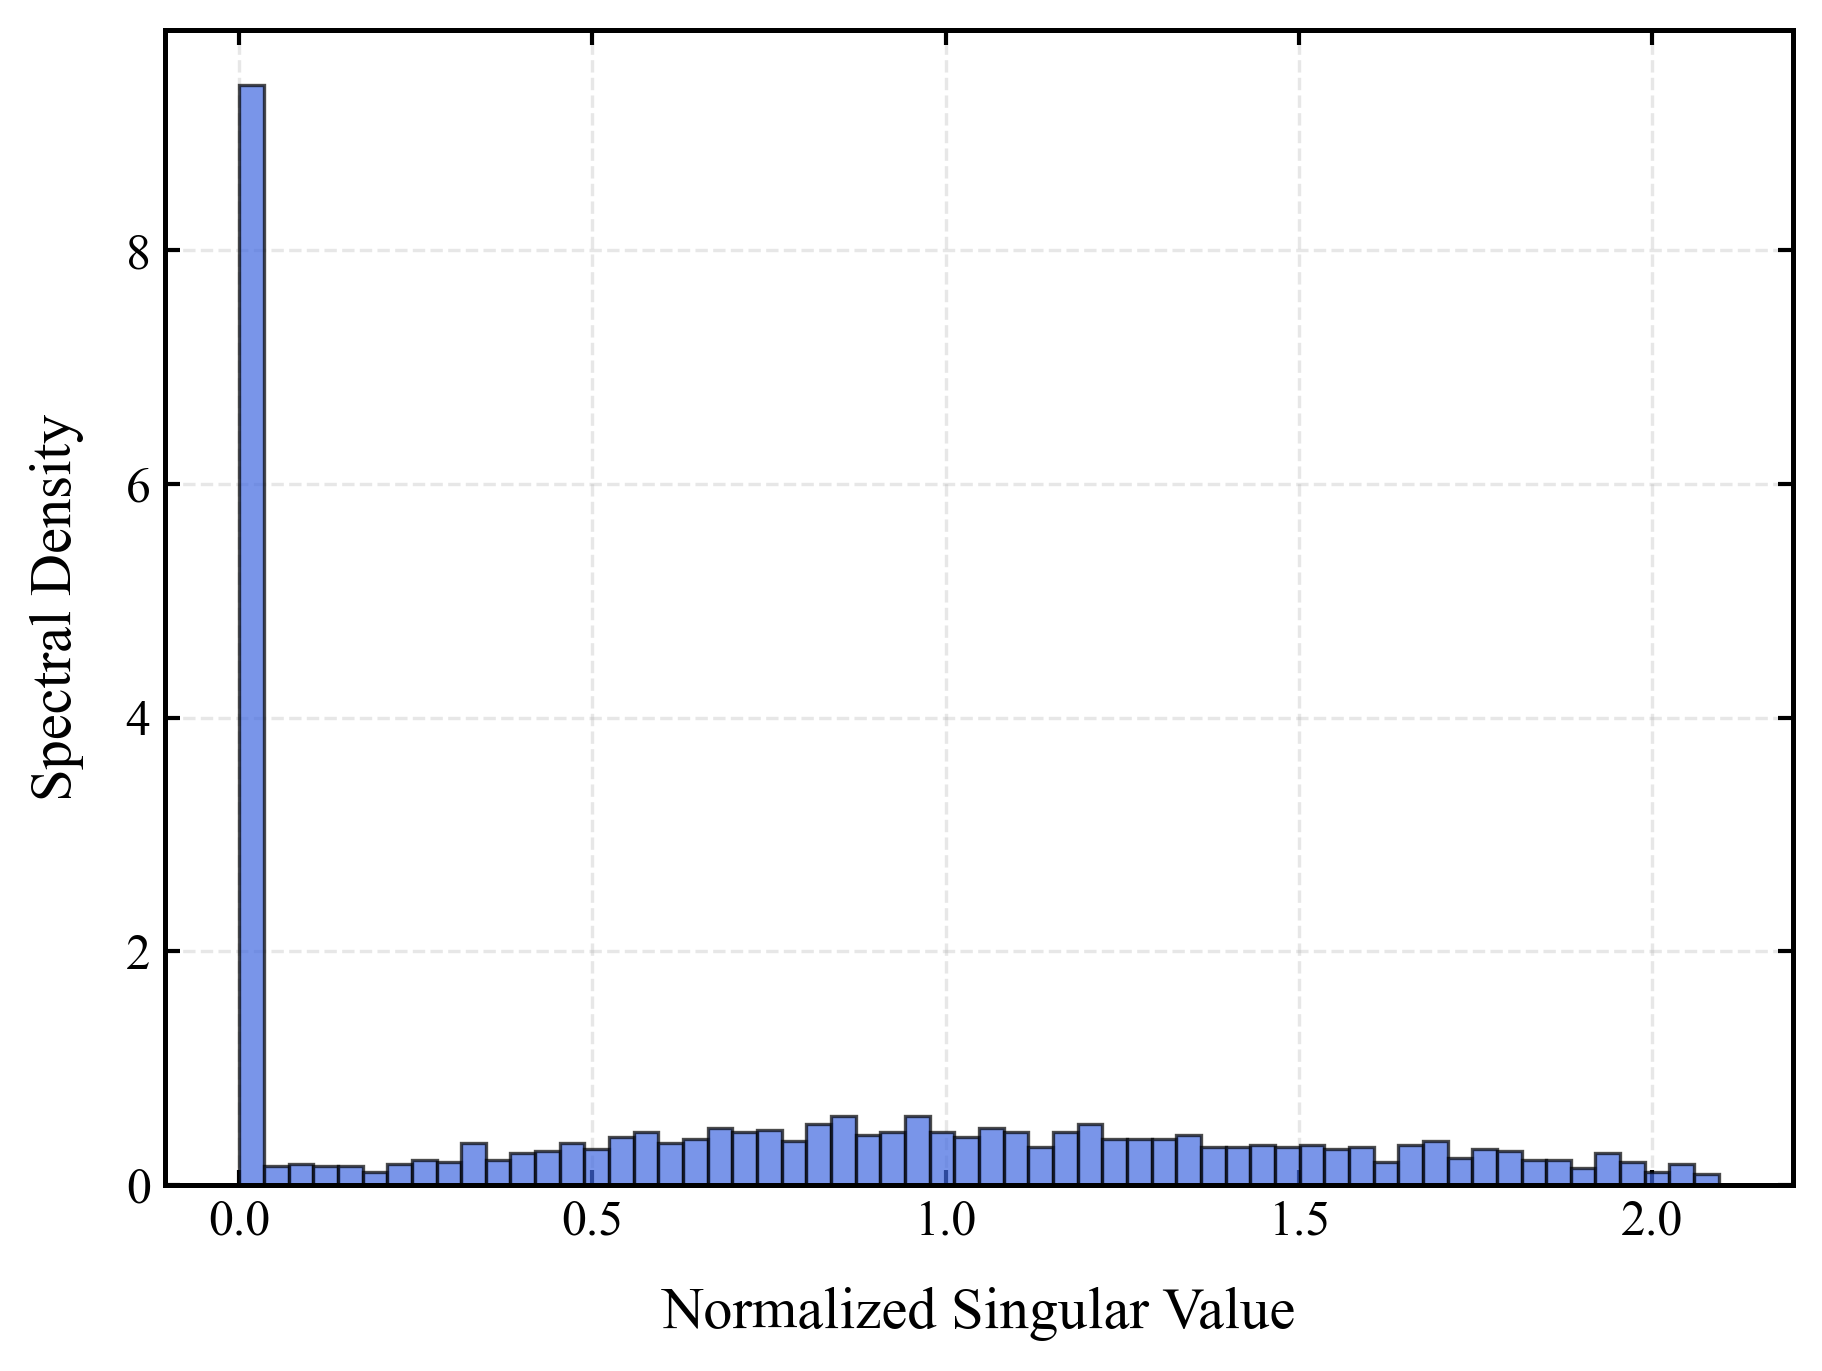

✅ Saved plot: ../results/run_20251213_1322/plots/SVD_Dist_lambda_0.001_W_runs_7.png


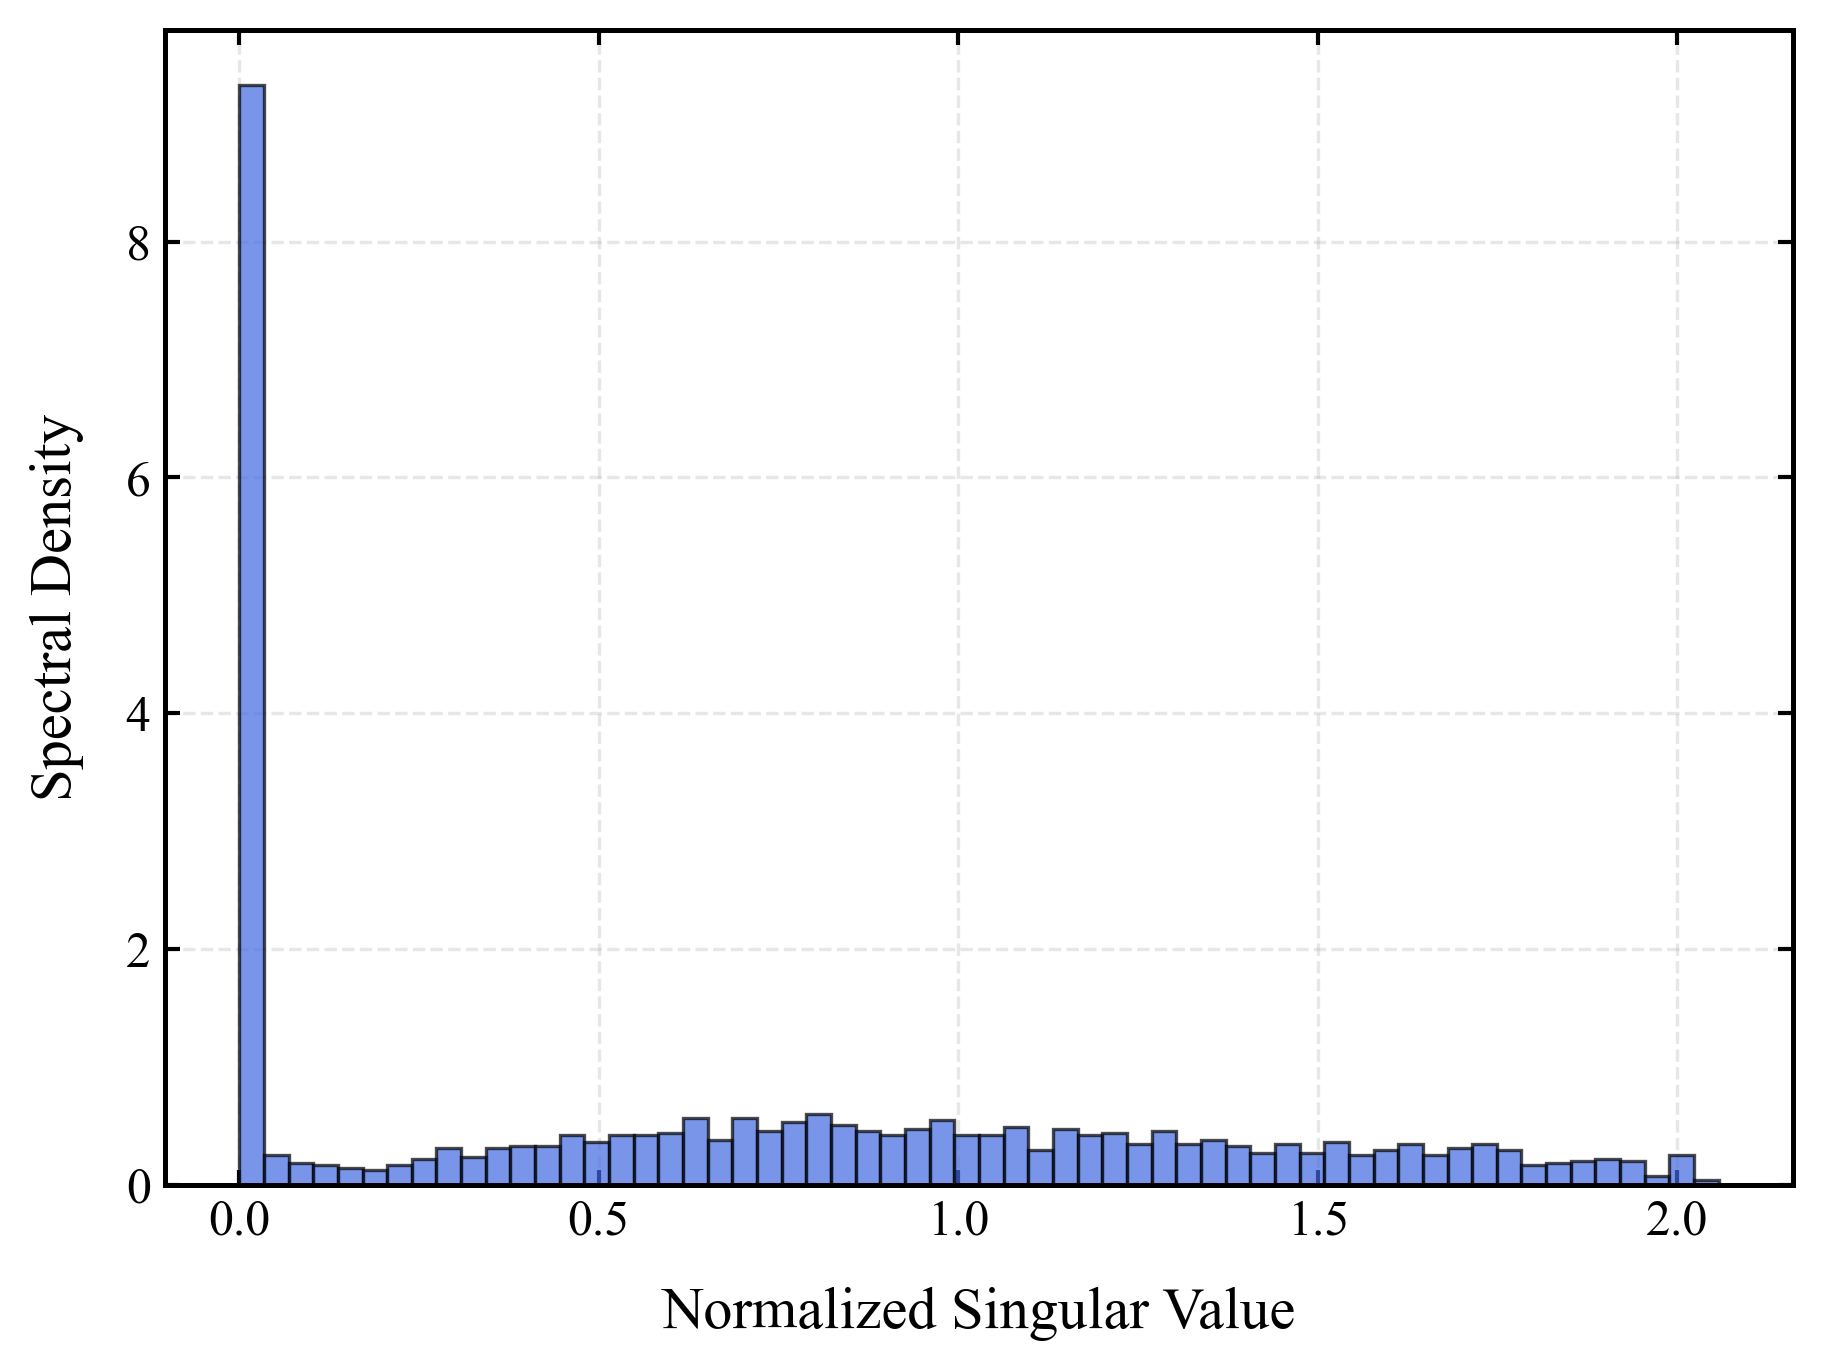

✅ Saved plot: ../results/run_20251213_1322/plots/SVD_Dist_lambda_0.001_W_runs_8.png


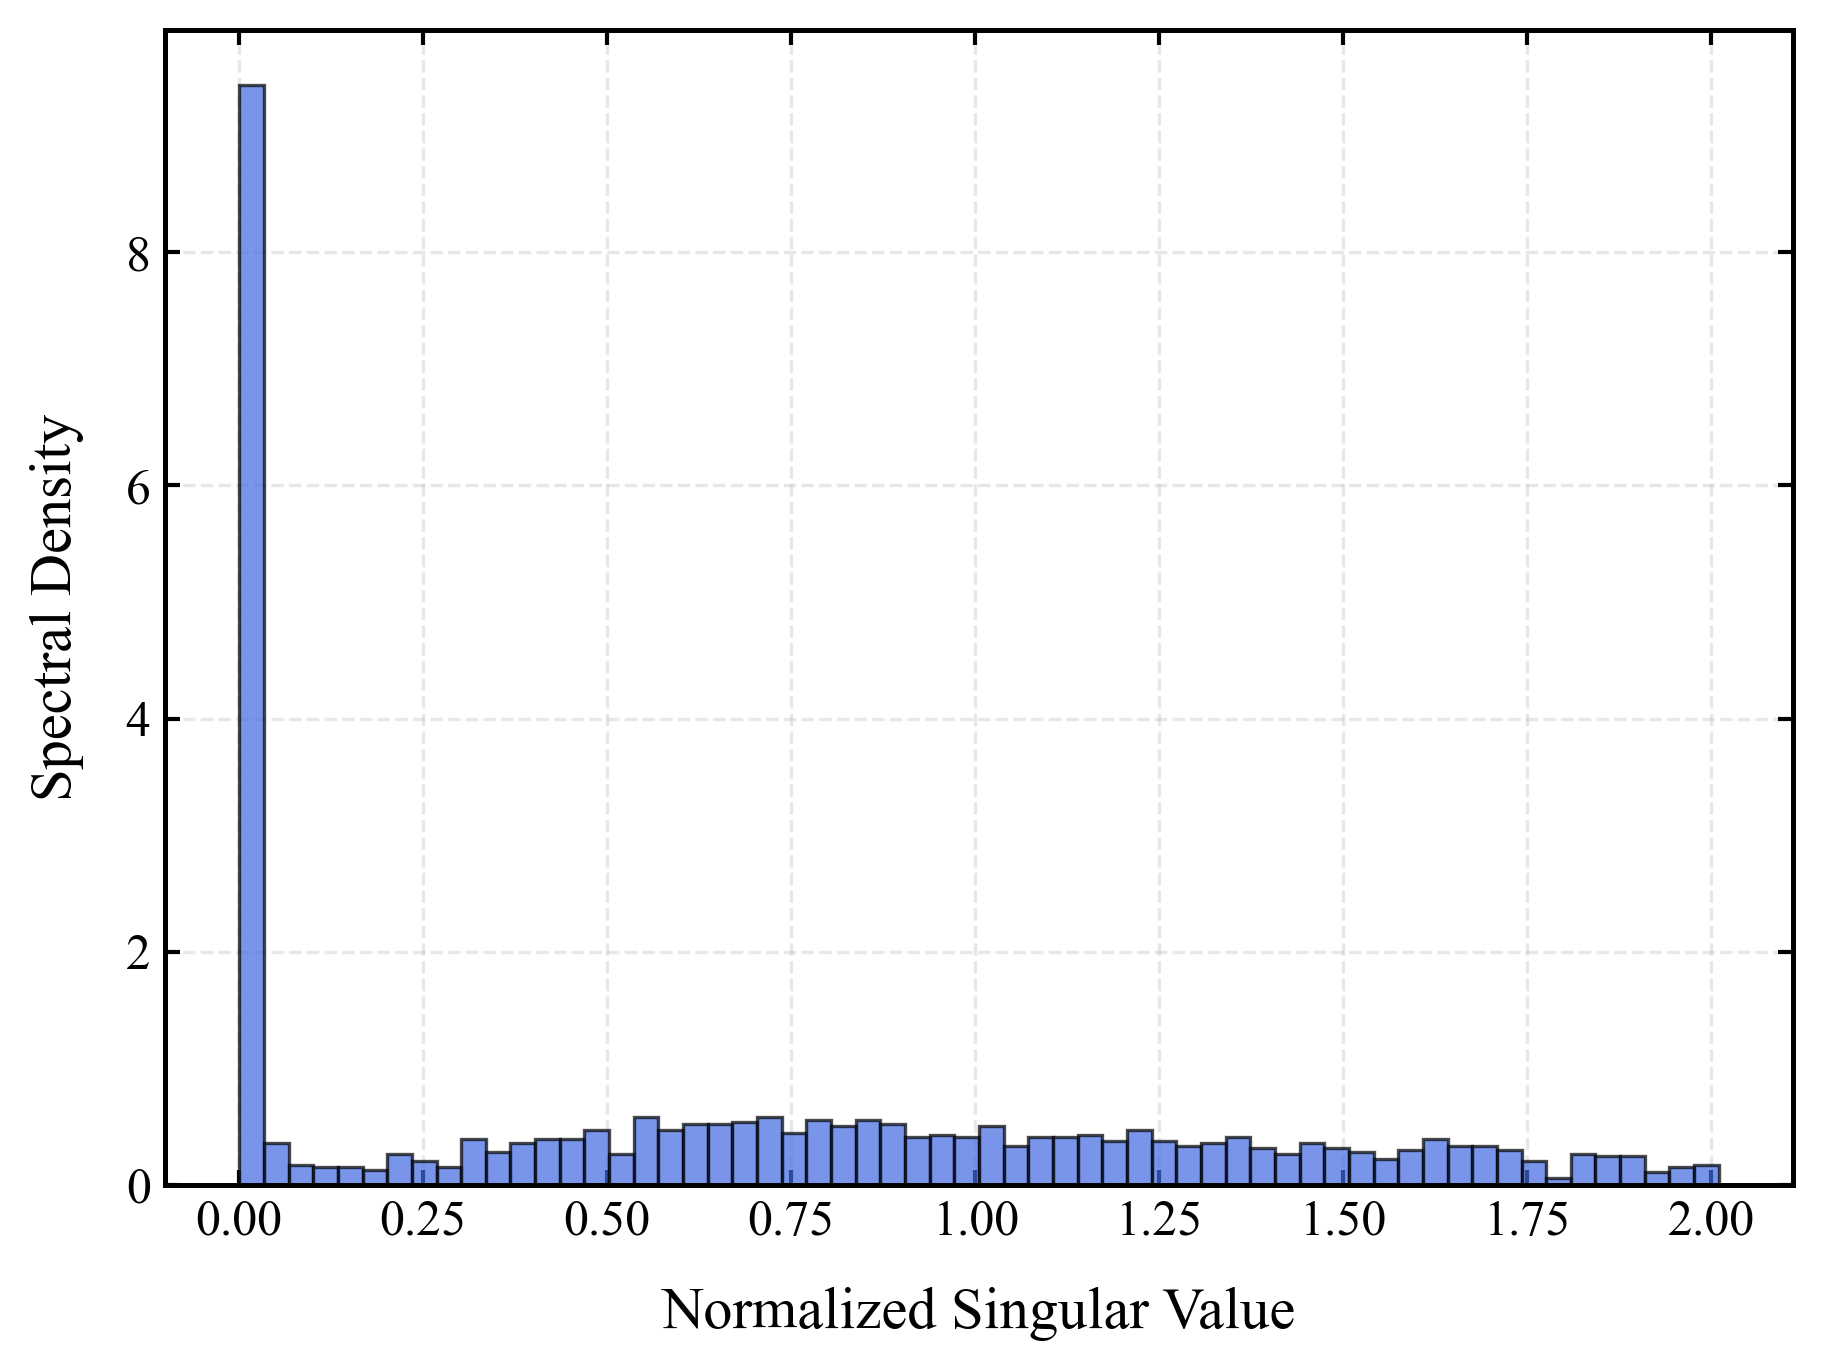

✅ Saved plot: ../results/run_20251213_1322/plots/SVD_Dist_lambda_0.001_W_runs_9.png


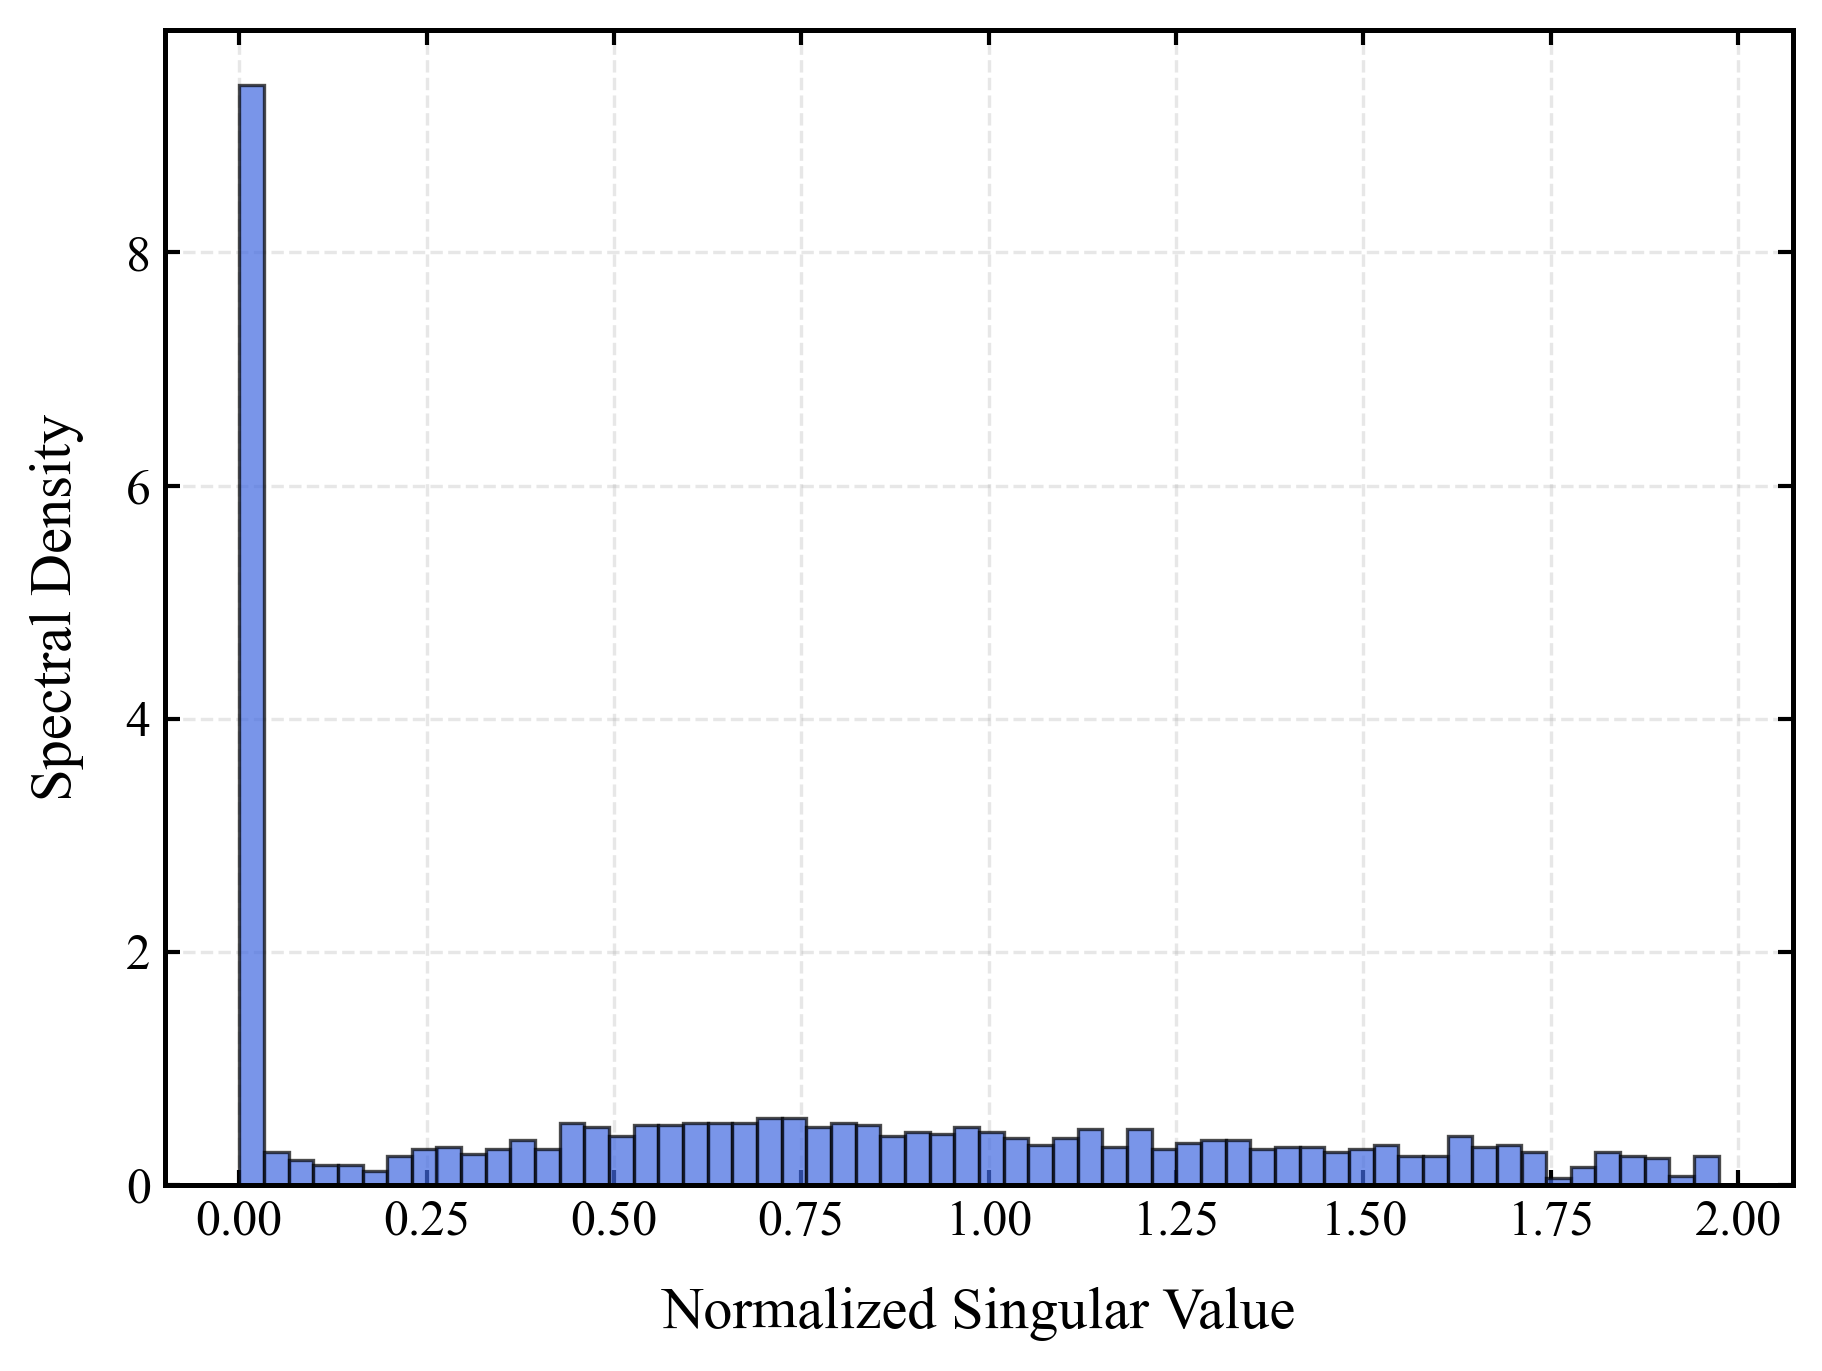

In [35]:
# --- 2. Paramètres ---
target_lambda = 0.001
lambda_candidates = [0.1, 0.01, 0.001, 0.0005, 0.0001, 1e-05]

# --- 3. Fonction de Plot ---
def plot_svd_distribution(singular_vals, lambda_val, filename, save_dir):
    fig, ax = plt.subplots(figsize=(7, 5))
    
    # Calcul des stats
    mu = np.mean(singular_vals)
    sigma = np.std(singular_vals)
    
    # Histogramme
    # density=True est préférable pour des papiers (indépendant du nombre d'échantillons)
    ax.hist(
        singular_vals, 
        bins=60, 
        density=True, 
        alpha=0.7, 
        color='royalblue', # Bleu standard "Academic"
        edgecolor='black', 
        linewidth=0.8,
        label=fr"$\lambda={lambda_val}$" + "\n" + fr"$\mu={mu:.2f}, \sigma={sigma:.2f}$"
    )
    
    # Labels
    ax.set_xlabel(r"Normalized Singular Value", labelpad=10)
    ax.set_ylabel("Spectral Density", labelpad=10)
    # ax.set_ylim(bottom=0, top=2) # Commencer à 0
    
    # Limites (Optionnel : à ajuster selon tes données)
    # ax.set_ylim([0, 5]) # Mieux vaut laisser auto au début
    
    # --- STYLE BOÎTE (Box Style) ---
    ax.set_axisbelow(True) # La grille passe derrière
    ax.tick_params(direction='in', top=True, right=True, which='both', width=1.0)
    
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.2)
        
    # Légende
    # ax.legend(frameon=True, fancybox=False, edgecolor='black', framealpha=1.0, loc='best')

    # Sauvegarde
    clean_name = filename.replace('.pkl', '')
    save_name = f"SVD_Dist_lambda_{lambda_val}_{clean_name}.png"
    full_path = os.path.join(save_dir, save_name)
    
    plt.savefig(full_path)
    print(f"✅ Saved plot: {full_path}")
    plt.show()

# --- 4. Logique Principale ---

# A. Récupération de l'index du Lambda
target_index = -1
for i, lam in enumerate(lambda_candidates):
    if np.isclose(lam, target_lambda, atol=1e-9):
        target_index = i
        break

if target_index == -1:
    print(f"❌ Erreur : Lambda {target_lambda} non trouvé dans {lambda_candidates}")
    # exit() # Commenté pour éviter de tuer le notebook si utilisé interactivement
else:
    print(f"🎯 Target Lambda {target_lambda} found at index {target_index}")

    # B. Chargement des fichiers
    pkl_files = sorted(glob.glob(os.path.join(run_dir, "W_runs_*.pkl")))
    print(f"📂 Found {len(pkl_files)} W_runs files.")

    for pkl_file in pkl_files:
        try:
            with open(pkl_file, "rb") as f:
                data_loaded = pickle.load(f)

            # Gestion Dictionnaire vs Liste
            if isinstance(data_loaded, dict) and "W_runs" in data_loaded:
                W_runs_all = data_loaded["W_runs"]
            else:
                W_runs_all = data_loaded

            # Vérification bornes
            if target_index >= len(W_runs_all):
                print(f"⚠️ Index {target_index} out of bounds for {os.path.basename(pkl_file)}. Skipping.")
                continue

            # Extraction
            W_list_target = W_runs_all[target_index] 
            
            # Uniformisation (si c'est un array unique, on le met dans une liste)
            if isinstance(W_list_target, np.ndarray) and W_list_target.ndim > 2:
                 # Cas où c'est un tenseur (n_samples, dim1, dim2)
                 W_list_target = list(W_list_target)
            elif isinstance(W_list_target, np.ndarray):
                # Cas matrice unique
                W_list_target = [W_list_target]

            # C. Calcul SVD
            all_singular_vals = []
            for W in W_list_target:
                # Calcul SVD (valeurs singulières uniquement)
                s_vals = np.linalg.svd(W, compute_uv=False)
                # Normalisation (selon ta logique originale : sqrt(lignes))
                norm_s_vals = s_vals / np.sqrt(W.shape[0])
                all_singular_vals.extend(norm_s_vals)

            all_singular_vals = np.array(all_singular_vals)

            # D. Plot
            plot_svd_distribution(
                all_singular_vals, 
                target_lambda, 
                os.path.basename(pkl_file), 
                plot_path if 'plot_path' in locals() else run_dir
            )

        except Exception as e:
            print(f"❌ Error processing {pkl_file}: {e}")